In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path
sys.path.append('/lab/barcheese01/smaffa/coTISja/src')

from scripts.plotting import *
from scripts.filter_utils import *
import re

pd.set_option('display.max_columns', None)

In [3]:
# from raw sample-level data
sample_level_tis_df = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/filtered_tis_data/combined/all_samples_filtered_with_protein_seq.csv')
sample_level_tis_df = calculate_normalization_factors(sample_level_tis_df, pseudocount=1)

# grab normalization factors
experiment_table, sample_df, replicate_df = load_experiment_manifest()
tisdiff_manifest = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/ribotish_tisdiff_manifest.tsv', sep='\t')
samples = experiment_table['sample'].tolist()
codon_order = ['ATG', 'ATA', 'ATC', 'ATT', 'ACG', 'AAG', 'AGG', 'GTG', 'TTG', 'CTG']
sample_to_riboseq_total = replicate_df[replicate_df['condition'] == 'TIS'].groupby('sample')['bam_qc_file'].apply(list).apply(lambda x: np.sum([calculate_read_totals_from_bam_qc(y) for y in x]))
sample_to_riboseq_scale_factor = (sample_to_riboseq_total.median() / sample_to_riboseq_total).rename('SampleRPFScaleFactor')
sample_level_tis_df = sample_level_tis_df.merge(sample_to_riboseq_scale_factor, left_on='Sample', right_index=True)

sample_level_tis_df = sample_level_tis_df.assign(
    TIS=sample_level_tis_df.apply(lambda x: f'{x["Tid"]}_{int(x["Start"])}_{x["GenomeStart"]}:{x["GenomePos"].split(":")[-1]}', axis=1)
)

# from DESeq2 transformation
vst_log_te_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/translation_efficiency_vst_matrix.csv', index_col=0)
deseq_log_te_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/log_translation_efficiency_coeffs.csv', index_col=0)
riboseq_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rpf_summed_replicate_counts.csv', index_col=0)
tis_mask = riboseq_counts >= 5
# riboseq_counts_masked = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rpf_summed_replicate_counts_masked.csv', index_col=0)
rna_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rna_summed_replicate_counts.csv', index_col=0)
rna_mask = rna_counts >= 5
# rna_counts_masked = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rna_summed_replicate_counts_masked.csv', index_col=0)
masked_te_matrix = vst_log_te_matrix[tis_mask & rna_mask].dropna(how='all')

# TIS metadata
replicate_level_tis_df = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/filtered_tis_data/per_rep/all_samples_filtered_with_protein_seq.csv')
replicate_level_tis_df = replicate_level_tis_df.assign(
    TIS=replicate_level_tis_df.apply(lambda x: f'{x["Tid"]}_{int(x["Start"])}_{x["GenomeStart"]}:{x["GenomePos"].split(":")[-1]}', axis=1)
)
tis_metadata = replicate_level_tis_df[['TIS', 'Tid', 'Symbol', 'Gid', 'GeneType', 'GenomeStart', 'StartCodon', 'Start', 'RecatTISType', 'MANE_Select', 'AALen', 'AASeq']].drop_duplicates(
    ['TIS']
)

/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log

In [ ]:
# calculate TE values
sample_level_tis_df = sample_level_tis_df.assign(
    LogTranslationEfficiency = lambda x: np.log2(x['SampleRPFScaleFactor'] * (x['TISCounts'] + 1)) - np.log2(x['SampleScaleFactor'] * (x['GeneRNASeqCounts'] + 1)),
    # LogTranslationEfficiency = lambda x: np.log2(x['TISCounts'] + 1) - np.log2(x['SampleScaleFactor'] * (x['GeneRNASeqCounts'] + 1)),
    TranslationEfficiency = lambda x: 2**x['LogTranslationEfficiency']
)

sns.kdeplot(
    sample_level_tis_df,
    x='LogTranslationEfficiency', hue='Sample'
)

In [6]:
# calculate TE values
sample_level_tis_df = sample_level_tis_df.assign(
    # LogTranslationEfficiency = lambda x: np.log2(x['SampleRPFScaleFactor'] * (x['TISCounts'] + 1)) - np.log2(x['SampleScaleFactor'] * (x['GeneRNASeqCounts'] + 1)),
    LogTranslationEfficiency = lambda x: np.log2(x['TISCounts'] + 1) - np.log2(x['SampleScaleFactor'] * (x['GeneRNASeqCounts'] + 1)),
    TranslationEfficiency = lambda x: 2**x['LogTranslationEfficiency']
)
sample_level_tis_df = sample_level_tis_df.assign(
    TIS=sample_level_tis_df.apply(lambda x: f'{x["Tid"]}_{int(x["Start"])}_{x["GenomeStart"]}:{x["GenomePos"].split(":")[-1]}', axis=1)
)

sns.kdeplot(
    sample_level_tis_df,
    x='LogTranslationEfficiency', hue='Sample'
)

In [17]:
sns.kdeplot(
    vst_log_te_matrix.melt(),
    x='value', hue='variable'
)

In [8]:
sns.kdeplot(
    vst_log_te_matrix[tis_mask].melt(),
    x='value', hue='variable'
)

In [9]:
sns.kdeplot(
    vst_log_te_matrix[rna_mask].melt(),
    x='value', hue='variable'
)

In [10]:
sns.kdeplot(
    vst_log_te_matrix[tis_mask & rna_mask].melt(),
    x='value', hue='variable'
)

In [12]:
sns.scatterplot(
    vst_log_te_matrix[tis_mask & rna_mask].melt(ignore_index=False, value_name='vst').reset_index().merge(
        deseq_log_te_matrix[tis_mask & rna_mask].melt(ignore_index=False, value_name='non_vst').reset_index()
    ),
    x='non_vst', y='vst',
)
plt.xlabel('Log TE')
plt.ylabel('Log TE with Variance-Stabilizing Transform (VST) ')

In [72]:
masked_te_matrix = vst_log_te_matrix[tis_mask & rna_mask].dropna(how='all')

In [14]:
sns.barplot((~(masked_te_matrix.isna())).sum().rename('N_TIS').reset_index().rename({'index': 'Sample'}, axis=1), x='Sample', y='N_TIS')
plt.ylabel('Number of TISs')

# Summarizing differential TIS metrics

1) Need to find a way to summarize per TIS, or make a function to extract when queried, the matrix of differential comparisons between samples
    - Done: exported stacked matrices per TIS over all pairs of samples
2) Want to find a way to summarize per TIS, the "outlier-ness" of translation efficiency values in any cell line, along with a statistical measure of this quantity - maybe these are worth experimentally testing
    - Ranking heuristic is ok: reporting the variance, maximum, and minimum of TE values, along with the most significant and median differential qvalue per TIS. Outliers should have high variance and a most significant q-value which is far from the median q-value. Conversely, non-outliers but differential across samples should have high variance, and a significant median q-value (i.e. more than half of pairwise comparisons should have significant differences in translation efficiency)
3) Want to report some statistical measure per TIS, of "interesting-ness" / "different-ness" across cell lines
    - TODO: some rank which combines these?
    - ranks for each (outlier-ness, vs. differential across all pairs)?
4) Need to make some gene-level comparisons with RNA expression or protein expression or essentiality across cell lines
    - TODO: use the highest ranking "differential across all pairs" or highest variance TISs as a subset of genes to run correlations with other measurements?
    - TODO: GO enrichment analysis on the genes with the most differential TISs?
5) Add functional annotations:
    - TODO: DeepLoc2.0
    - SLiM enrichment within the differential domains
    - TODO: Presence of peptide in mass spec data

In [85]:
pairwise_wald_tests = dict()
for f in os.listdir('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/pairwise_wald'):
    sample_match = re.search('(.+)_vs_(.+).csv', f)
    s1, s2 = sample_match.groups()
    pairwise_wald_tests[(s1, s2)] = pd.read_csv(f'/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/pairwise_wald/{f}', index_col=0)

In [86]:
# function to pull out statistics for a TIS across all pairwise comparisons
def extract_TIS_matrix(TIS, pairwise_dict=pairwise_wald_tests, comparison_metric='log2FoldChange', masked_tis_matrix=masked_te_matrix):
    single_samples = set()
    for s1, s2 in pairwise_dict:
        single_samples.add(s1)
        single_samples.add(s2)
    single_samples = sorted(list(single_samples))
    n_samples = len(single_samples)

    output_matrix = np.empty(shape=(n_samples, n_samples))
    output_matrix.fill(np.nan)
    output_matrix = pd.DataFrame(output_matrix, index=single_samples, columns=single_samples)

    for pair, df in pairwise_dict.items():
        s1, s2 = pair
        if TIS in df.index.tolist():
            output_matrix.loc[s1, s2] = df.loc[TIS, comparison_metric]
        if masked_tis_matrix is not None:
            if TIS in masked_tis_matrix.index.tolist() and s1 in masked_tis_matrix.columns.tolist() and s2 in masked_tis_matrix.columns.tolist():
                if np.isnan(masked_tis_matrix.loc[TIS, s1]) and np.isnan(masked_tis_matrix.loc[TIS, s2]):
                    output_matrix.loc[s1, s2] = np.nan

    return output_matrix

In [87]:
def extract_TIS_block(comparison_metric='log2FoldChange', pairwise_dict=pairwise_wald_tests, masked_tis_matrix=masked_te_matrix):
    single_samples = set()
    tis_superindex = set()
    for s1, s2 in pairwise_dict:
        single_samples.add(s1)
        single_samples.add(s2)
        tis_superindex = tis_superindex.union(pairwise_dict[(s1, s2)].index.tolist())
    single_samples = sorted(list(single_samples))
    tis_superindex = sorted(list(tis_superindex))
    n_samples = len(single_samples)
    n_tis = len(tis_superindex)

    sample_index = pd.Series(range(n_samples), index=single_samples)
    tis_index = pd.Series(range(n_tis), index=tis_superindex)

    output_matrix = np.empty(shape=(n_tis, n_samples, n_samples))
    output_matrix.fill(np.nan)

    for pair, df in tqdm(pairwise_dict.items()):
        s1, s2 = pair
        output_matrix[:, sample_index.loc[s1], sample_index.loc[s2]] = df.reindex(index=tis_superindex)[comparison_metric].values

        if masked_tis_matrix is not None:
            na_mask = masked_tis_matrix.reindex(index=tis_superindex)[[s1, s2]].isna().all(axis=1).tolist()
            output_matrix[na_mask, sample_index.loc[s1], sample_index.loc[s2]] = np.nan

    output_block = pd.DataFrame(
        output_matrix.reshape(tis_index.shape[0] * sample_index.shape[0], sample_index.shape[0]),
        index=pd.MultiIndex.from_product([tis_index.index.tolist(), sample_index.index.tolist()], names=['TIS', 'TestSample']),
        columns=sample_index.index.tolist()
    )
    output_block.columns.name='RefSample'
    return output_block

In [88]:
lfc_block = extract_TIS_block(comparison_metric='log2FoldChange')
pval_block = extract_TIS_block(comparison_metric='pvalue')
qval_block = extract_TIS_block(comparison_metric='padj')

In [19]:
lfc_block.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/lfc_matrix_stack.csv')
pval_block.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/pval_matrix_stack.csv')
qval_block.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/qval_matrix_stack.csv')

In [20]:
lfc_block = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/lfc_matrix_stack.csv', index_col=[0, 1])
lfc_block.columns.name = 'RefSample'
pval_block = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/pval_matrix_stack.csv', index_col=[0, 1])
pval_block.columns.name = 'RefSample'
qval_block = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/qval_matrix_stack.csv', index_col=[0, 1])
qval_block.columns.name = 'RefSample'

In [31]:
extract_TIS_matrix('ENST00000624697.4_245_chr1:1013998:+', masked_tis_matrix=None)

In [ ]:
extract_TIS_matrix('ENST00000624697.4_245_chr1:1013998:+', masked_tis_matrix=None, comparison_metric='padj')

In [ ]:
extract_TIS_matrix('ENST00000624697.4_245_chr1:1013998:+')

In [89]:
def calculate_variance_shifts(matrix, baseline_variance=None):
    """
    Calculates the changes in variance across the rows after removing each column
    """
    if baseline_variance is None:
        baseline_variance = matrix.var(axis=1)
    column_dropped_to_remaining_variance = dict()
    for c in matrix.columns:
        column_dropped_to_remaining_variance[c] = matrix.drop([c], axis=1).var(axis=1).rename(c)
    dropped_variances = pd.concat(column_dropped_to_remaining_variance, axis=1)

    variance_shifts = (dropped_variances.T - baseline_variance).T
    variance_shifts[~(matrix.isna()) & dropped_variances.isna()] = -np.inf
    return variance_shifts, dropped_variances

def calculate_range_shifts(matrix):
    """
    Calculates the changes in range across the rows after removing each column
    """
    baseline_range = matrix.max(axis=1) - matrix.min(axis=1)
    column_dropped_to_remaining_range = dict()
    for c in matrix.columns:
        dropped_matrix = matrix.drop([c], axis=1)
        column_dropped_to_remaining_range[c] = (dropped_matrix.max(axis=1) - dropped_matrix.min(axis=1)).rename(c)
    dropped_ranges = pd.concat(column_dropped_to_remaining_range, axis=1)

    range_shifts = (dropped_ranges.T - baseline_range).T
    return range_shifts, dropped_ranges

In [99]:
# measure of uniqueness across cell lines
# 1) how many cell lines is the TIS detected in?
# 2) what is the variance in the translation efficiency across cell lines?
#   a) ranks are maybe only consistent within groups by number of cell lines
n_samples_per_tis = (~masked_te_matrix.isna()).sum(axis=1).rename('NSamples')
variance_per_tis = masked_te_matrix.var(axis=1).rename('LogTEVariance')

variance_shifts, dropped_variances = calculate_variance_shifts(masked_te_matrix, baseline_variance=variance_per_tis)
min_delta_variance = variance_shifts.min(axis=1).rename('LeaveOneOutLargestDeltaVariance')
range_shifts, dropped_ranges = calculate_range_shifts(masked_te_matrix)
min_delta_range = range_shifts.min(axis=1).rename('LeaveOneOutLargestDeltaRange')
min_delta_variance_sample = variance_shifts.idxmin(axis=1).rename('CandidateOutlier')

min_te_per_tis = masked_te_matrix.min(axis=1).rename('MinLogRiboOverRNA')
min_te_sample_per_tis = masked_te_matrix.dropna(how='all').idxmin(axis=1).rename('MinLogTESample')
max_te_per_tis = masked_te_matrix.max(axis=1).rename('MaxLogRiboOverRNA')
max_te_sample_per_tis = masked_te_matrix.dropna(how='all').idxmax(axis=1).rename('MaxLogTESample')

lfc_reshaped = lfc_block.melt(ignore_index=False).reset_index().pivot(index='TIS', columns=['TestSample', 'RefSample'], values='value')
qval_reshaped = qval_block.melt(ignore_index=False).reset_index().pivot(index='TIS', columns=['TestSample', 'RefSample'], values='value')
min_lfc_per_tis = lfc_reshaped.min(axis=1).rename('MinLFC')
min_lfc_pair_per_tis = lfc_reshaped.dropna(how='all').idxmin(axis=1).apply(lambda x: '/'.join(x)).rename('MinLFCSamplePair')
max_lfc_per_tis = lfc_reshaped.max(axis=1).rename('MaxLFCSamplePair')
max_lfc_pair_per_tis = lfc_reshaped.dropna(how='all').idxmax(axis=1).apply(lambda x: '/'.join(x)).rename('MaxLFCSamplePair')
min_diffq_per_tis = qval_reshaped.min(axis=1).rename('MinDiffQVal')
min_diffq_pair_per_tis = qval_reshaped.dropna(how='all').idxmin(axis=1).apply(lambda x: '/'.join(x)).rename('MinDiffQValSamplePair')
median_diffq_per_tis = qval_reshaped.median(axis=1).rename('MedianDiffQVal')
max_diffq_per_tis = qval_reshaped.max(axis=1).rename('MaxDiffQVal')
min_median_diffq_magnitude_diff_per_tis = (np.log10(min_diffq_per_tis) - np.log10(median_diffq_per_tis)).abs().rename('QValMinMedianMagnitudeDiff')

In [23]:
directions = []
for tis, min_idx in tqdm(qval_reshaped.dropna(how='all').idxmin(axis=1).items()):
    directions.append(np.sign(lfc_reshaped.loc[tis, min_idx]))
most_sig_direction_per_tis = pd.Series(directions, index=qval_reshaped.dropna(how='all').index).rename('MinDiffQValDirection')

In [24]:
max_riboseq_counts_per_tis = riboseq_counts.max(axis=1).rename('MaxRiboseqCounts')
max_riboseq_rpm_per_tis = ((riboseq_counts / sample_to_riboseq_total) * 1e6).max(axis=1).rename('MaxRiboseqRPM')
max_riboseq_sample_per_tis = ((riboseq_counts / sample_to_riboseq_total) * 1e6).idxmax(axis=1).rename('MaxRiboseqSample')
min_riboseq_counts_per_tis = riboseq_counts.min(axis=1).rename('MinRiboseqCounts')
min_riboseq_rpm_per_tis = ((riboseq_counts / sample_to_riboseq_total) * 1e6).min(axis=1).rename('MinRiboseqRPM')
min_riboseq_sample_per_tis = ((riboseq_counts / sample_to_riboseq_total) * 1e6).idxmin(axis=1).rename('MinRiboseqSample')

In [63]:
tis_stats = pd.concat([
    n_samples_per_tis, variance_per_tis,
    max_riboseq_counts_per_tis, max_riboseq_rpm_per_tis, max_riboseq_sample_per_tis, min_riboseq_counts_per_tis, min_riboseq_rpm_per_tis, min_riboseq_sample_per_tis,
    max_te_per_tis, max_te_sample_per_tis, min_te_per_tis, min_te_sample_per_tis,
    max_lfc_per_tis, max_lfc_pair_per_tis, min_lfc_per_tis, min_lfc_pair_per_tis, most_sig_direction_per_tis,
    min_diffq_per_tis, min_diffq_pair_per_tis, median_diffq_per_tis, max_diffq_per_tis, min_median_diffq_magnitude_diff_per_tis,
    min_delta_variance, min_delta_range, min_delta_variance_sample
], axis=1)
tis_summary = tis_metadata.merge(tis_stats, left_on='TIS', right_index=True)
tis_summary = tis_summary.dropna(subset=['NSamples'])

In [90]:
def summarize_tis_stats_across_samples(
    te_matrix=masked_te_matrix, 
    lfc_stack=lfc_block, qval_stack=qval_block, 
    tis_counts=riboseq_counts, total_tis_counts=sample_to_riboseq_total, tis_metadata_df=tis_metadata, 
    sample_subset=samples
):
    # reshape inputs depending on sample subset
    te_matrix = te_matrix.loc[:, sample_subset]
    lfc_stack = lfc_stack.loc[pd.IndexSlice[:, sample_subset], sample_subset]
    qval_stack = qval_stack.loc[pd.IndexSlice[:, sample_subset], sample_subset]
    tis_counts = tis_counts.loc[:, sample_subset]
    total_tis_counts = total_tis_counts.loc[sample_subset]

    # overall metrics on presence and variability across samples
    n_samples_per_tis = (~(te_matrix.isna())).sum(axis=1).rename('NSamples')
    variance_per_tis = te_matrix.var(axis=1).rename('LogTEVariance')

    # outlier detection by changes in spread
    variance_shifts, dropped_variances = calculate_variance_shifts(te_matrix, baseline_variance=variance_per_tis)
    min_delta_variance = variance_shifts.min(axis=1).rename('LeaveOneOutLargestDeltaVariance')
    range_shifts, dropped_ranges = calculate_range_shifts(te_matrix)
    min_delta_range = range_shifts.min(axis=1).rename('LeaveOneOutLargestDeltaRange')
    min_delta_variance_sample = variance_shifts.dropna(how='all').idxmin(axis=1).rename('CandidateOutlier').reindex(index=min_delta_variance.index)

    # Ribo/RNA values
    min_te_per_tis = te_matrix.min(axis=1).rename('MinLogRiboOverRNA')
    min_te_sample_per_tis = te_matrix.dropna(how='all').idxmin(axis=1).rename('MinLogTESample')
    max_te_per_tis = te_matrix.max(axis=1).rename('MaxLogRiboOverRNA')
    max_te_sample_per_tis = te_matrix.dropna(how='all').idxmax(axis=1).rename('MaxLogTESample')

    # metrics of fold changes and q-values for all pairwise comparisons
    lfc_reshaped = lfc_stack.melt(ignore_index=False).reset_index().pivot(index='TIS', columns=['TestSample', 'RefSample'], values='value')
    qval_reshaped = qval_stack.melt(ignore_index=False).reset_index().pivot(index='TIS', columns=['TestSample', 'RefSample'], values='value')
    min_lfc_per_tis = lfc_reshaped.min(axis=1).rename('MinLFC')
    min_lfc_pair_per_tis = lfc_reshaped.dropna(how='all').idxmin(axis=1).apply(lambda x: '/'.join(x)).rename('MinLFCSamplePair')
    max_lfc_per_tis = lfc_reshaped.max(axis=1).rename('MaxLFCSamplePair')
    max_lfc_pair_per_tis = lfc_reshaped.dropna(how='all').idxmax(axis=1).apply(lambda x: '/'.join(x)).rename('MaxLFCSamplePair')
    min_diffq_per_tis = qval_reshaped.min(axis=1).rename('MinDiffQVal')
    min_diffq_pair_per_tis = qval_reshaped.dropna(how='all').idxmin(axis=1).apply(lambda x: '/'.join(x)).rename('MinDiffQValSamplePair')
    median_diffq_per_tis = qval_reshaped.median(axis=1).rename('MedianDiffQVal')
    max_diffq_per_tis = qval_reshaped.max(axis=1).rename('MaxDiffQVal')
    min_median_diffq_magnitude_diff_per_tis = (np.log10(min_diffq_per_tis) - np.log10(median_diffq_per_tis)).abs().rename('QValMinMedianMagnitudeDiff')

    # direction of outlier change
    directions = []
    for tis, min_idx in tqdm(qval_reshaped.dropna(how='all').idxmin(axis=1).items()):
        directions.append(np.sign(lfc_reshaped.loc[tis, min_idx]))
    most_sig_direction_per_tis = pd.Series(directions, index=qval_reshaped.dropna(how='all').index).rename('MinDiffQValDirection')

    # data on raw counts
    max_riboseq_counts_per_tis = tis_counts.max(axis=1).rename('MaxRiboseqCounts')
    max_riboseq_rpm_per_tis = ((tis_counts / total_tis_counts) * 1e6).max(axis=1).rename('MaxRiboseqRPM')
    max_riboseq_sample_per_tis = ((tis_counts / total_tis_counts) * 1e6).idxmax(axis=1).rename('MaxRiboseqSample')
    min_riboseq_counts_per_tis = tis_counts.min(axis=1).rename('MinRiboseqCounts')
    min_riboseq_rpm_per_tis = ((tis_counts / total_tis_counts) * 1e6).min(axis=1).rename('MinRiboseqRPM')
    min_riboseq_sample_per_tis = ((tis_counts / total_tis_counts) * 1e6).idxmin(axis=1).rename('MinRiboseqSample')

    # merge metrics together
    tis_stats = pd.concat([
        n_samples_per_tis, variance_per_tis,
        max_riboseq_counts_per_tis, max_riboseq_rpm_per_tis, max_riboseq_sample_per_tis, min_riboseq_counts_per_tis, min_riboseq_rpm_per_tis, min_riboseq_sample_per_tis,
        max_te_per_tis, max_te_sample_per_tis, min_te_per_tis, min_te_sample_per_tis,
        max_lfc_per_tis, max_lfc_pair_per_tis, min_lfc_per_tis, min_lfc_pair_per_tis, most_sig_direction_per_tis,
        min_diffq_per_tis, min_diffq_pair_per_tis, median_diffq_per_tis, max_diffq_per_tis, min_median_diffq_magnitude_diff_per_tis,
        min_delta_variance, min_delta_range, min_delta_variance_sample
    ], axis=1)
    tis_summary = tis_metadata_df.merge(tis_stats, left_on='TIS', right_index=True)
    tis_summary = tis_summary.dropna(subset=['NSamples'])

    return tis_summary

In [91]:
tis_summary = summarize_tis_stats_across_samples(
    te_matrix=masked_te_matrix, 
    lfc_stack=lfc_block, qval_stack=qval_block, 
    tis_counts=riboseq_counts, total_tis_counts=sample_to_riboseq_total, tis_metadata_df=tis_metadata, 
    sample_subset=samples
)

In [92]:
tis_summary.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/deseq2_tis_summary_statistics.csv', index=False)

In [111]:
tis_summary = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/deseq2_tis_summary_statistics.csv')

In [33]:
from matplotlib.patches import Rectangle, Patch

def plot_tis_over_cell_lines(transcript_id, tis_summary_df=tis_summary, te_matrix=masked_te_matrix, 
                             figsize=(16, 3), range_extension=0.01, cds_height_scale=0.05, position_width=2.4, 
                             sample_palette='tab10', tis_type_palette='Set2', upstream_crop=100):
    
    def extend_lims(lims, extension_scale):
        if isinstance(extension_scale, tuple):
            left_ext_scale, right_ext_scale = extension_scale
        else:
            left_ext_scale = extension_scale
            right_ext_scale = extension_scale
        lim_range = lims[1] - lims[0]
        extended_lim = (lims[0] - left_ext_scale * lim_range, lims[1] + right_ext_scale * lim_range)
        return extended_lim

    df = tis_summary_df[
        tis_summary_df['Tid'].str.contains(transcript_id)
    ].sort_values('Start')[['TIS', 'Start', 'RecatTISType']].merge(
        te_matrix, left_on='TIS', right_index=True
    ).set_index(['TIS', 'Start', 'RecatTISType']).melt(ignore_index=False, var_name='Sample', value_name='LogTE').reset_index().dropna(subset=['LogTE'])
    symbol = tis_summary_df[tis_summary_df['Tid'].str.contains(transcript_id)]['Symbol'].iloc[0]

    # get key x value markers
    gene_5utr_body = (0, df['Start'].max())
    # extended_xlim = extend_lims(gene_5utr_body, range_extension)
    # xrange = gene_5utr_body[1] - gene_5utr_body[0]
    # extended_xlim = (gene_5utr_body[0] - range_extension * xrange, gene_5utr_body[1] + range_extension * xrange)

    # get yrange
    ylims = (df['LogTE'].min(), df['LogTE'].max())
    extended_ylim = extend_lims(ylims, range_extension)
    # yrange = ylims[1] - ylims[0]
    # extended_ylim = (ylims[0] - range_extension * yrange, ylims[1] + range_extension * yrange)
    gene_cds_height = cds_height_scale * (extended_ylim[1] - extended_ylim[0])

    # organize all of the starts and associated metadata for plotting
    unique_starts = sorted(df['Start'].unique().tolist())
    unique_samples = sorted(df['Sample'].unique().tolist())
    unique_tis_types = sorted(df['RecatTISType'].unique().tolist())
    sample_width = position_width / len(unique_samples)
    sample_rect_xpos = pd.Series(np.arange(-position_width/2, position_width/2, sample_width), index=unique_samples)
    start_to_tis_type = df.drop_duplicates(['Start', 'RecatTISType']).set_index('Start')['RecatTISType']

    # assign colors to the TE bars
    if isinstance(sample_palette, str):
        sample_palette = pd.Series(sns.color_palette(sample_palette, n_colors=len(unique_samples)), index=unique_samples)
    elif isinstance(sample_palette, dict):
        sample_palette = pd.Series(sample_palette)
    elif not isinstance(sample_palette, pd.Series):
        raise TypeError('`sample_palette`')
    
    # assign colors to the TIS annotations
    if isinstance(tis_type_palette, str):
        tis_type_palette = pd.Series(sns.color_palette(tis_type_palette, n_colors=len(unique_tis_types)), index=unique_tis_types)
    elif isinstance(tis_type_palette, dict):
        tis_type_palette = pd.Series(tis_type_palette)
    elif not isinstance(tis_type_palette, pd.Series):
        raise TypeError('`tis_type_palette`')

    fig, axs = plt.subplots(2, 1, figsize=figsize, sharex=True, height_ratios=[1, 9])
    
    # plot the TIS annotations
    for start in unique_starts:
        axs[1].axvline(start-position_width/2, color='black', linestyle='dotted', alpha=0.2)
        axs[1].axvline(start+position_width/2, color='black', linestyle='dotted', alpha=0.2)
        tis_type = start_to_tis_type.loc[start]
        block_width = position_width/3
        axs[0].add_patch(Rectangle((start-block_width/2, -gene_cds_height), block_width, 2*gene_cds_height, facecolor=tis_type_palette.loc[tis_type], linewidth=0, fill=True, zorder=1))

    # may need to readjust figure bounds depending on the interaction between start positions and sample offsets
    empirical_min_x = df['Start'].iloc[0]
    empirical_max_x = gene_5utr_body[1]
    for i, r in df.iterrows():
        start = r['Start']
        sample = r['Sample']
        height = r['LogTE']

        if height < 0:
            xy = (start + sample_rect_xpos.loc[sample], height)
            ht = -height
        else:
            xy = (start + sample_rect_xpos.loc[sample], 0)
            ht = height
        axs[1].add_patch(Rectangle(xy, sample_width, ht, edgecolor='black', facecolor=sample_palette.loc[sample], linewidth=0.1, fill=True))
        if xy[0] < empirical_min_x:
            empirical_min_x = xy[0]
        if (xy[0] + sample_width) > empirical_max_x:
            empirical_max_x = xy[0] + sample_width
            
    # set axis labels
    axs[1].set_xlabel('TIS position relative to transcript start')
    axs[1].set_ylabel('Log2(Ribo / RNA)')
    axs[0].set_title(f'{transcript_id} ({symbol})')
    axs[0].set_axis_off()

    # set axis limits
    if (gene_5utr_body[0] + upstream_crop) < empirical_min_x:
        # nothing within `upstream_crop`` upstream of the first TIS
        final_xlims = extend_lims((empirical_min_x, empirical_max_x), range_extension)
    else:
        final_xlims = extend_lims((gene_5utr_body[0], empirical_max_x), range_extension)
    # axs[0].set_xlim(left_coordinate, empirical_max_x)
    # axs[1].set_xlim(left_coordinate, empirical_max_x)
    axs[0].set_xlim(final_xlims[0], final_xlims[1])
    axs[1].set_xlim(final_xlims[0], final_xlims[1])
    axs[1].set_ylim(extended_ylim[0], extended_ylim[1])
    axs[1].axhline(0, color='black', linestyle='dashed')
    axs[0].plot([gene_5utr_body[0], final_xlims[1]], [0, 0], color='black', linewidth=1, zorder=0) # full transcript body
    if df[df['RecatTISType'] == 'Annotated'].shape[0] > 0: # we know where the start is
        annotated_start = df[df['RecatTISType'] == 'Annotated']['Start'].iloc[0]
        axs[0].add_patch(Rectangle((annotated_start, -gene_cds_height/2), final_xlims[1] - annotated_start, gene_cds_height, edgecolor='black', facecolor='black', fill=True, zorder=0)) # annotated CDS

    axs[1].legend(
        handles = [Patch(facecolor='white', edgecolor='white', label='TIS Type')] + 
        [
            Patch(facecolor=c, edgecolor='white', label=t) for t, c in tis_type_palette.items()
        ] + [Patch(facecolor='white', edgecolor='white', label='Sample')] + [
            Patch(facecolor=c, edgecolor='white', label=s) for s, c in sample_palette.items()
        ], loc='lower left', bbox_to_anchor=(1, -0.1)
    )


In [28]:
tis_summary[
    tis_summary['MANE_Select'] &
    ~tis_summary['RecatTISType'].isin(['Annotated'])
].sort_values(by=['NSamples','LogTEVariance'], ascending=[False, False]).head(25)

In [36]:
tis_summary[
    tis_summary['MANE_Select'] &
    ~tis_summary['RecatTISType'].isin(['Annotated'])
].sort_values(by=['NSamples','LogTEVariance'], ascending=[False, False]).head(25).loc[:, 'AASeq'].iloc[1]

In [37]:
tis_summary[
    tis_summary['MANE_Select'] &
    tis_summary['RecatTISType'].isin(['Annotated'])
].sort_values(by=['NSamples','LogTEVariance'], ascending=[False, False]).head(25).loc[:, 'AASeq'].iloc[1]

In [160]:
df = tis_summary[
    tis_summary['Tid'] == 'ENST00000366553.3'
].sort_values('Start')[['TIS', 'Start', 'RecatTISType']].merge(
    masked_te_matrix, left_on='TIS', right_index=True
).set_index(['TIS', 'Start', 'RecatTISType']).melt(ignore_index=False, var_name='Sample').reset_index()

fig, axs = plt.subplots(6, 1, figsize=(6, 10), sharex=True, sharey=True)

for i, s in enumerate(samples):
    sns.barplot(
        df[df['Sample'] == s],
        x='Start', y='value', hue='RecatTISType', ax=axs[i], legend=False
    )
    axs[i].axhline(0, linestyle='dashed', color='black')
    axs[i].set_ylabel(f'{s}\n(Ribo / RNA)')
axs[0].set_title('CHML')

In [159]:
df = tis_summary[
    tis_summary['Tid'] == 'ENST00000642928.2'
].sort_values('Start')[['TIS', 'Start', 'RecatTISType']].merge(
    masked_te_matrix, left_on='TIS', right_index=True
).set_index(['TIS', 'Start', 'RecatTISType']).melt(ignore_index=False, var_name='Sample').reset_index()

fig, axs = plt.subplots(6, 1, figsize=(6, 10), sharex=True, sharey=True)

for i, s in enumerate(samples):
    sns.barplot(
        df[df['Sample'] == s],
        x='Start', y='value', hue='RecatTISType', ax=axs[i], legend=False
    )
    axs[i].axhline(0, linestyle='dashed', color='black')
    axs[i].set_ylabel(f'{s}\n(Ribo / RNA)')
axs[0].set_title('CD59')

In [165]:
df = tis_summary[
    tis_summary['Tid'] == 'ENST00000359995.10'
].sort_values('Start')[['TIS', 'Start', 'RecatTISType']].merge(
    masked_te_matrix, left_on='TIS', right_index=True
).set_index(['TIS', 'Start', 'RecatTISType']).melt(ignore_index=False, var_name='Sample').reset_index()

fig, axs = plt.subplots(6, 1, figsize=(6, 10), sharex=True, sharey=True)

for i, s in enumerate(samples):
    sns.barplot(
        df[df['Sample'] == s],
        x='Start', y='value', hue='RecatTISType', ax=axs[i], legend=False
    )
    axs[i].axhline(0, linestyle='dashed', color='black')
    axs[i].set_ylabel(f'{s}\n(Ribo / RNA)')
axs[0].set_title('SRSF1')

## Check for SLiM enrichment in the differential protein sequences between canonical and non-canonical starts

In [46]:
# sequence_differential_df = pair_canonical_isoforms(
#     sample_level_tis_df, id_columns=['Sample', 'Tid'], canonical_columns=['Start', 'StartCodon', 'AALen', 'AASeq'], downstream_calculations=False
# ).drop_duplicates(subset=['Tid', 'Start'])[['TIS', 'RecatTISType', 'Start', 'CanonicalStart',  'AASeq', 'CanonicalAASeq', 'AALen', 'CanonicalAALen']]

sequence_differential_df = pair_canonical_isoforms(
    replicate_level_tis_df, id_columns=['Sample', 'Tid'], canonical_columns=['Start', 'StartCodon', 'AALen', 'AASeq'], downstream_calculations=False
).drop_duplicates(subset=['Tid', 'Start'])[['TIS', 'RecatTISType', 'Start', 'CanonicalStart',  'AASeq', 'CanonicalAASeq', 'AALen', 'CanonicalAALen']].dropna(subset=['AASeq', 'CanonicalAASeq'])

In [47]:
differential_sequences = pd.concat([
    sequence_differential_df['TIS'],
    sequence_differential_df.apply(
        lambda x: x['AASeq'][:int(x['AALen'] - x['CanonicalAALen'])] if x['RecatTISType'] == 'Extended' else
            x['CanonicalAASeq'][:int(x['CanonicalAALen'] - x['AALen'])] if x['RecatTISType'] == 'Truncated' else
            x['AASeq'] if x['RecatTISType'] in ['uORF', 'Other'] else None,
        axis=1
    ).rename('AASeqDiffFromCanonical')
], axis=1)

In [48]:
slim_classes = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/external/elm_slim_classes.tsv', sep='\t', skiprows=5)

def scan_regex_patterns(series, pattern_df=slim_classes, id_colname='ELMIdentifier'):
    pattern_presence_matrix = []
    for i, r in tqdm(pattern_df.iterrows()):
        id_name = r[id_colname]
        pattern = r['Regex']
        pattern_presence_matrix.append(series.apply(lambda x: True if re.search(pattern, x) else False).rename(id_name))
    return pd.concat(pattern_presence_matrix, axis=1)

In [49]:
slim_presence_matrix = scan_regex_patterns(differential_sequences.set_index('TIS')['AASeqDiffFromCanonical'])

In [50]:
tis_i, slim_i = np.where(slim_presence_matrix)
slim_grouper_df = pd.DataFrame({'TIS_i': tis_i, 'SLiM_i': slim_i}).merge(
    pd.DataFrame({'TIS_i': range(slim_presence_matrix.shape[0]), 'TIS': slim_presence_matrix.index})
).merge(
    pd.DataFrame({'SLiM_i': range(slim_presence_matrix.shape[1]), 'SLiM': slim_presence_matrix.columns})
).merge(
    slim_classes, left_on=['SLiM'], right_on=['ELMIdentifier']
)

In [51]:
slim_ids = slim_grouper_df.groupby('TIS')['ELMIdentifier'].apply(list)
slim_func_names = slim_grouper_df.groupby('TIS')['FunctionalSiteName'].apply(lambda x: list(set(x)))
slim_descriptions = slim_grouper_df.groupby('TIS')['Description'].apply(lambda x: list(set(x)))

In [52]:
slim_analysis_df = differential_sequences.merge(
    pd.concat([slim_ids.apply(lambda x: '|'.join(x)).rename('AASeqDiff_ELMIdentifier'), 
               slim_func_names.apply(lambda x: '|'.join(x)).rename('AASeqDiff_FunctionSiteName'), 
               slim_descriptions.apply(lambda x: '|'.join(x)).rename('AASeqDiff_Description')], axis=1),
    left_on='TIS', right_index=True
)

In [33]:
slim_analysis_df.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/differential_aaseq_slim_analysis.csv', index=False)

In [94]:
slim_analysis_df = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/differential_aaseq_slim_analysis.csv')

## Separate tables into (1) Continuous variation across cell lines; and (6) Outliers for each cell line

### How to set good thresholds for outliers

In [34]:
sns.kdeplot(
    tis_summary[tis_summary['MinDiffQVal'] < 0.01], 
    x='QValMinMedianMagnitudeDiff', hue='NSamples', palette='tab10'
)
sns.kdeplot(
    tis_summary[tis_summary['MedianDiffQVal'] < 0.01], 
    x='QValMinMedianMagnitudeDiff', hue='NSamples', palette='tab10', alpha=0.5
)
plt.xlim(-5, 15)

In [35]:
sns.kdeplot(
    tis_summary[tis_summary['MedianDiffQVal'] < 0.01], 
    x='QValMinMedianMagnitudeDiff', hue='NSamples'
)
plt.xlim(-5, 25)

In [36]:
sns.kdeplot(
    tis_summary[(tis_summary['MinDiffQVal'] < 0.01) & (tis_summary['NSamples'] >= 5)], 
    x='QValMinMedianMagnitudeDiff',
)
sns.kdeplot(
    tis_summary[(tis_summary['MedianDiffQVal'] < 0.01) & (tis_summary['NSamples'] >= 5)], 
    x='QValMinMedianMagnitudeDiff',
)
plt.axvline(6, linestyle='dashed', color='tab:red', alpha=0.5)

In [40]:
sns.kdeplot(
    tis_summary[(tis_summary['MedianDiffQVal'] < 0.01) & (tis_summary['NSamples'] >= 5)], 
    x='QValMinMedianMagnitudeDiff',
)
plt.axvline(
    np.quantile(tis_summary[(tis_summary['MedianDiffQVal'] < 0.01) & (tis_summary['NSamples'] >= 5)]['QValMinMedianMagnitudeDiff'], 0.5), 
    linestyle='dashed', color='tab:red', alpha=0.5
)

In [41]:
np.quantile(tis_summary[(tis_summary['MedianDiffQVal'] < 0.01) & (tis_summary['NSamples'] >= 6)]['QValMinMedianMagnitudeDiff'], 0.5)

In [394]:
def calculate_qval_magnitude_boundary(tis_summary, max_significance=0.01, min_samples=6):
    # sns.kdeplot(
    #     tis_summary[(tis_summary['MinDiffQVal'] < max_significance) & (tis_summary['NSamples'] >= min_samples)], 
    #     x='QValMinMedianMagnitudeDiff', label='Min Q-value < 0.01 ("Outlier" or "Continuum")'
    # )
    # outlier_x, outlier_y = plt.gca().get_lines()[-1].get_data()
    # sns.kdeplot(
    #     tis_summary[(tis_summary['MedianDiffQVal'] < max_significance) & (tis_summary['NSamples'] >= min_samples)], 
    #     x='QValMinMedianMagnitudeDiff', label='Median Q-value < 0.01 ("Continuum")'
    # )
    # trend_x, trend_y = plt.gca().get_lines()[-1].get_data()
    # midpoint_x = np.mean([trend_x[np.argmax(trend_y)], outlier_x[np.argmax(outlier_y)]])
    # plt.axvline(midpoint_x, linestyle='dashed', color='tab:red', alpha=0.5, label=f'Midpoint between modes ({midpoint_x:.2f})')
    # plt.legend()
    # plt.show()

    # return midpoint_x

    sns.kdeplot(
        tis_summary[(tis_summary['MedianDiffQVal'] < max_significance) & (tis_summary['NSamples'] >= min_samples)], 
        x='QValMinMedianMagnitudeDiff', label='Median Q-value < 0.01 ("Continuum")'
    )
    q = np.quantile(tis_summary[(tis_summary['MedianDiffQVal'] < 0.01) & (tis_summary['NSamples'] >= 5)]['QValMinMedianMagnitudeDiff'], 0.5)
    plt.axvline(q, linestyle='dashed', color='tab:red', alpha=0.5, label=f'Midpoint between modes ({q:.2f})')
    plt.legend()
    plt.show()
    return q

In [395]:
magnitude_boundary = calculate_qval_magnitude_boundary(tis_summary)

In [408]:
tis_summary[
    (tis_summary['QValMinMedianMagnitudeDiff'] > magnitude_boundary)# &
    # (tis_summary['MinDiffQValSamplePair'].str.contains(s))
]

In [20]:
tis_summary[(tis_summary['QValMinMedianMagnitudeDiff'] > 10)].sort_values(
    'LeaveOneOutLargestDeltaVariance', ascending=False).query('RecatTISType.isin(["Extended", "Truncated"])')

In [57]:
tis_summary[(tis_summary['Symbol'] == 'ACTG1')].sort_values(
    'LeaveOneOutLargestDeltaVariance', ascending=False).query('RecatTISType.isin(["Extended", "Truncated"])')

In [56]:
plot_tis_over_cell_lines('ENST00000575994.6')

In [166]:
plot_tis_over_cell_lines('ENST00000369632.6')

In [168]:
plot_tis_over_cell_lines('ENST00000374500.10')

In [164]:
plot_tis_over_cell_lines('ENST00000228136.9')

In [170]:
for t in tis_summary[(tis_summary['QValMinMedianMagnitudeDiff'] > 10)].sort_values(
    'LeaveOneOutLargestDeltaVariance', ascending=False).query('RecatTISType.isin(["Extended", "Truncated"])')['Tid'].head(10).unique().tolist():
    plot_tis_over_cell_lines(t)

In [42]:
sns.kdeplot(tis_summary[(tis_summary['QValMinMedianMagnitudeDiff'] > 5)], x='LeaveOneOutLargestDeltaVariance')
sns.kdeplot(tis_summary[(tis_summary['QValMinMedianMagnitudeDiff'] > 10)], x='LeaveOneOutLargestDeltaVariance')
plt.gca().axvline(-0.63)

In [ ]:
# qval_magnitude_diff = 5
# outlier_df = []
# for s in samples:
#     if s == 'HeLa':
#         outlier_subset = tis_summary[
#             ((tis_summary['QValMinMedianMagnitudeDiff'] > qval_magnitude_diff) & # requirement for outlier
#              ((tis_summary['MinDiffQValDirection'] < 0) & # first cell line is a negative outlier or second cell line is a positive outlier
#               ((tis_summary['MinDiffQValSamplePair'].str.startswith(s) & (tis_summary['MinLogTESample'] == s)) | 
#                (tis_summary['MinDiffQValSamplePair'].str.endswith(s) & (tis_summary['MaxLogTESample'] == s))) |
#               ((tis_summary['MinDiffQValDirection'] > 0) & # first cell line is a positive outlier or second cell line is a negative outlier
#                (tis_summary['MinDiffQValSamplePair'].str.startswith(s) & (tis_summary['MaxLogTESample'] == s)) |
#                (tis_summary['MinDiffQValSamplePair'].str.endswith(s) & (tis_summary['MinLogTESample'] == s))))) |
#             (tis_summary['NSamples'] == 1) & (tis_summary['MaxDiffQVal'] < 0.01) & (tis_summary['MaxRiboseqSample'] == s)
#         ]
#         outlier_subset = outlier_subset.assign(LikelyOutlier=s)
#     else:
#         outlier_subset = tis_summary[
#             ((tis_summary['QValMinMedianMagnitudeDiff'] > qval_magnitude_diff) & # requirement for outlier
#              ((tis_summary['MinDiffQValDirection'] < 0) & # first cell line is a negative outlier or second cell line is a positive outlier
#               ((tis_summary['MinDiffQValSamplePair'].str.startswith(s) & (tis_summary['MinLogTESample'] == s)) | 
#                (tis_summary['MinDiffQValSamplePair'].str.endswith(s) & (tis_summary['MaxLogTESample'] == s))) |
#               ((tis_summary['MinDiffQValDirection'] > 0) & # first cell line is a positive outlier or second cell line is a negative outlier
#                (tis_summary['MinDiffQValSamplePair'].str.startswith(s) & (tis_summary['MaxLogTESample'] == s)) |
#                (tis_summary['MinDiffQValSamplePair'].str.endswith(s) & (tis_summary['MinLogTESample'] == s)))) &
#              (~tis_summary['MinDiffQValSamplePair'].str.contains('HeLa'))) |
#             (tis_summary['NSamples'] == 1) & (tis_summary['MaxDiffQVal'] < 0.01) & (tis_summary['MaxRiboseqSample'] == s)
#         ]
#         outlier_subset = outlier_subset.assign(LikelyOutlier=s)
#     print(s, len(outlier_subset))
#     outlier_df.append(outlier_subset)
# outlier_df = pd.concat(outlier_df, axis=0)
# outlier_df = outlier_df[~(outlier_df['RecatTISType'].isin(['Annotated']))]

In [95]:
qval_magnitude_diff = 10
min_outlier_effect_size = np.log2(2) # 2x foldchange
max_min_qval = 0.01
min_range_shift = np.log2(1.5) # 1.5x foldchange more than next largest

outlier_df = tis_summary[
    ((tis_summary['NSamples'] >= 3) & # outlier from other defined samples
     (tis_summary['QValMinMedianMagnitudeDiff'] > max(qval_magnitude_diff, -np.log10(max_min_qval))) &
     (tis_summary['LeaveOneOutLargestDeltaRange'].abs() > min_range_shift) &
     (((tis_summary['CandidateOutlier'] == tis_summary['MaxLogTESample']) &  # figure out whether it is a positive or negative outlier and threshold the corresponding one
       (tis_summary['MaxLogRiboOverRNA'].abs() >= min_outlier_effect_size)) |
      ((tis_summary['CandidateOutlier'] == tis_summary['MinLogTESample']) & 
       (tis_summary['MinLogRiboOverRNA'].abs() >= min_outlier_effect_size)))) |
    ((tis_summary['NSamples'] == 1) & # outlier because only one sample detected
     (tis_summary['MinDiffQVal'] <= max_min_qval) &
     (tis_summary['MaxLogRiboOverRNA'].abs() >= min_outlier_effect_size)) # only one value defined - this value is both max and min
]
outlier_df = outlier_df[~outlier_df['RecatTISType'].isin(['Annotated'])]

In [96]:
func_annotated_outlier_df = outlier_df.merge(slim_analysis_df, how='left')
func_annotated_outlier_df = func_annotated_outlier_df.sort_values(by=['NSamples', 'LogTEVariance'], ascending=[False, False])

In [52]:
plot_tis_over_cell_lines(func_annotated_outlier_df.loc[1994].loc['Tid'], tis_summary, masked_te_matrix)

In [97]:
func_annotated_outlier_df.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/alternative_translation_efficiency_outliers.csv')

In [99]:
qval_magnitude_diff = 5
max_median_qval = 0.01
min_samples = 3

continuum_df = tis_summary[
    (tis_summary['QValMinMedianMagnitudeDiff'] < qval_magnitude_diff) &
    (tis_summary['MedianDiffQVal'] < max_median_qval) & 
    (tis_summary['NSamples'] >= min_samples) &
    ~(tis_summary['RecatTISType'].isin(['Annotated']))
]

In [100]:
func_annotated_continuum_df = continuum_df.merge(slim_analysis_df, how='left')
func_annotated_continuum_df = func_annotated_continuum_df.sort_values(by=['NSamples', 'LogTEVariance'], ascending=[False, False])

In [101]:
func_annotated_continuum_df.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/alternative_translation_efficiency_continuous.csv')

In [102]:
tis_summary['Class'] = 'None'
tis_summary.loc[tis_summary['TIS'].isin(func_annotated_outlier_df['TIS'].tolist()), 'Class'] = 'Outlier'
tis_summary.loc[tis_summary['TIS'].isin(func_annotated_continuum_df['TIS'].tolist()), 'Class'] = 'Continuous'
tis_summary.value_counts('Class')

In [239]:
for t in func_annotated_outlier_df[func_annotated_outlier_df['MANE_Select']].head(10)['Tid'].unique().tolist():
    print(func_annotated_outlier_df[func_annotated_outlier_df['Tid'] == t]['Symbol'].iloc[0], 
          func_annotated_outlier_df[func_annotated_outlier_df['Tid'] == t].head(10)['Start'].tolist())
    plot_tis_over_cell_lines(t)

In [551]:
plot_tis_over_cell_lines('ENST00000228136.9')

In [240]:
for t in func_annotated_continuum_df[func_annotated_continuum_df['MANE_Select']].head(10)['Tid'].unique().tolist():
    print(func_annotated_continuum_df[func_annotated_continuum_df['Tid'] == t]['Symbol'].iloc[0], 
          func_annotated_continuum_df[func_annotated_continuum_df['Tid'] == t].head(10)['Start'].tolist())
    plot_tis_over_cell_lines(t)

## Perform analysis again, pre-blocking the conditions to test

In [131]:
def summarize_tis_stats_across_samples(
    te_matrix=masked_te_matrix, 
    lfc_stack=lfc_block, qval_stack=qval_block, 
    tis_counts=riboseq_counts, total_tis_counts=sample_to_riboseq_total, tis_metadata_df=tis_metadata, 
    sample_subset=samples
):
    # reshape inputs depending on sample subset
    te_matrix = te_matrix.loc[:, sample_subset]
    lfc_stack = lfc_stack.loc[pd.IndexSlice[:, sample_subset], sample_subset]
    qval_stack = qval_stack.loc[pd.IndexSlice[:, sample_subset], sample_subset]
    tis_counts = tis_counts.loc[:, sample_subset]
    total_tis_counts = total_tis_counts.loc[sample_subset]

    # overall metrics on presence and variability across samples
    n_samples_per_tis = (~(te_matrix.isna())).sum(axis=1).rename('NSamples')
    variance_per_tis = te_matrix.var(axis=1).rename('LogTEVariance')

    # outlier detection by changes in spread
    variance_shifts, dropped_variances = calculate_variance_shifts(te_matrix, baseline_variance=variance_per_tis)
    min_delta_variance = variance_shifts.min(axis=1).rename('LeaveOneOutLargestDeltaVariance')
    range_shifts, dropped_ranges = calculate_range_shifts(te_matrix)
    min_delta_range = range_shifts.min(axis=1).rename('LeaveOneOutLargestDeltaRange')
    min_delta_variance_sample = variance_shifts.dropna(how='all').idxmin(axis=1).rename('CandidateOutlier').reindex(index=min_delta_variance.index)

    # Ribo/RNA values
    min_te_per_tis = te_matrix.min(axis=1).rename('MinLogRiboOverRNA')
    min_te_sample_per_tis = te_matrix.dropna(how='all').idxmin(axis=1).rename('MinLogTESample')
    max_te_per_tis = te_matrix.max(axis=1).rename('MaxLogRiboOverRNA')
    max_te_sample_per_tis = te_matrix.dropna(how='all').idxmax(axis=1).rename('MaxLogTESample')

    # metrics of fold changes and q-values for all pairwise comparisons
    lfc_reshaped = lfc_stack.melt(ignore_index=False).reset_index().pivot(index='TIS', columns=['TestSample', 'RefSample'], values='value')
    qval_reshaped = qval_stack.melt(ignore_index=False).reset_index().pivot(index='TIS', columns=['TestSample', 'RefSample'], values='value')
    min_lfc_per_tis = lfc_reshaped.min(axis=1).rename('MinLFC')
    min_lfc_pair_per_tis = lfc_reshaped.dropna(how='all').idxmin(axis=1).apply(lambda x: '/'.join(x)).rename('MinLFCSamplePair')
    max_lfc_per_tis = lfc_reshaped.max(axis=1).rename('MaxLFCSamplePair')
    max_lfc_pair_per_tis = lfc_reshaped.dropna(how='all').idxmax(axis=1).apply(lambda x: '/'.join(x)).rename('MaxLFCSamplePair')
    min_diffq_per_tis = qval_reshaped.min(axis=1).rename('MinDiffQVal')
    min_diffq_pair_per_tis = qval_reshaped.dropna(how='all').idxmin(axis=1).apply(lambda x: '/'.join(x)).rename('MinDiffQValSamplePair')
    median_diffq_per_tis = qval_reshaped.median(axis=1).rename('MedianDiffQVal')
    max_diffq_per_tis = qval_reshaped.max(axis=1).rename('MaxDiffQVal')
    min_median_diffq_magnitude_diff_per_tis = (np.log10(min_diffq_per_tis) - np.log10(median_diffq_per_tis)).abs().rename('QValMinMedianMagnitudeDiff')

    # direction of outlier change
    directions = []
    for tis, min_idx in tqdm(qval_reshaped.dropna(how='all').idxmin(axis=1).items()):
        directions.append(np.sign(lfc_reshaped.loc[tis, min_idx]))
    most_sig_direction_per_tis = pd.Series(directions, index=qval_reshaped.dropna(how='all').index).rename('MinDiffQValDirection')

    # data on raw counts
    max_riboseq_counts_per_tis = tis_counts.max(axis=1).rename('MaxRiboseqCounts')
    max_riboseq_rpm_per_tis = ((tis_counts / total_tis_counts) * 1e6).max(axis=1).rename('MaxRiboseqRPM')
    max_riboseq_sample_per_tis = ((tis_counts / total_tis_counts) * 1e6).idxmax(axis=1).rename('MaxRiboseqSample')
    min_riboseq_counts_per_tis = tis_counts.min(axis=1).rename('MinRiboseqCounts')
    min_riboseq_rpm_per_tis = ((tis_counts / total_tis_counts) * 1e6).min(axis=1).rename('MinRiboseqRPM')
    min_riboseq_sample_per_tis = ((tis_counts / total_tis_counts) * 1e6).idxmin(axis=1).rename('MinRiboseqSample')

    # merge metrics together
    tis_stats = pd.concat([
        n_samples_per_tis, variance_per_tis,
        max_riboseq_counts_per_tis, max_riboseq_rpm_per_tis, max_riboseq_sample_per_tis, min_riboseq_counts_per_tis, min_riboseq_rpm_per_tis, min_riboseq_sample_per_tis,
        max_te_per_tis, max_te_sample_per_tis, min_te_per_tis, min_te_sample_per_tis,
        max_lfc_per_tis, max_lfc_pair_per_tis, min_lfc_per_tis, min_lfc_pair_per_tis, most_sig_direction_per_tis,
        min_diffq_per_tis, min_diffq_pair_per_tis, median_diffq_per_tis, max_diffq_per_tis, min_median_diffq_magnitude_diff_per_tis,
        min_delta_variance, min_delta_range, min_delta_variance_sample
    ], axis=1)
    tis_summary = tis_metadata_df.merge(tis_stats, left_on='TIS', right_index=True)
    tis_summary = tis_summary.dropna(subset=['NSamples'])

    return tis_summary

In [103]:
riboseq_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rpf_summed_replicate_counts.csv', index_col=0)
tis_mask = riboseq_counts >= 5
rna_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rna_summed_replicate_counts.csv', index_col=0)
rna_mask = rna_counts >= 5

In [104]:
cell_line_samples = ['HeLa', 'K562', 'RPE1_Async', 'U2OS']

cell_line_pairwise_wald_tests = dict()
for f in os.listdir('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/cell_lines/pairwise_wald'):
    sample_match = re.search('(.+)_vs_(.+).csv', f)
    s1, s2 = sample_match.groups()
    cell_line_pairwise_wald_tests[(s1, s2)] = pd.read_csv(f'/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/cell_lines/pairwise_wald/{f}', index_col=0)

cell_line_tis_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/cell_lines/translation_efficiency_vst_matrix.csv', index_col=0)
cell_line_tis_matrix = cell_line_tis_matrix[tis_mask.reindex_like(cell_line_tis_matrix) & rna_mask.reindex_like(cell_line_tis_matrix)]

cell_line_lfc_block = extract_TIS_block(comparison_metric='log2FoldChange', pairwise_dict=cell_line_pairwise_wald_tests, masked_tis_matrix=cell_line_tis_matrix)
cell_line_qval_block = extract_TIS_block(comparison_metric='padj', pairwise_dict=cell_line_pairwise_wald_tests, masked_tis_matrix=cell_line_tis_matrix)

In [105]:
cell_line_tis_summary = summarize_tis_stats_across_samples(
    te_matrix=cell_line_tis_matrix, 
    lfc_stack=cell_line_lfc_block, qval_stack=cell_line_qval_block, 
    tis_counts=riboseq_counts, total_tis_counts=sample_to_riboseq_total, tis_metadata_df=tis_metadata, 
    sample_subset=cell_line_samples
)

In [106]:
cell_line_tis_summary.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/cell_lines/deseq2_tis_summary_statistics.csv', index=False)

In [107]:
rpe1_samples = ['RPE1_Async', 'RPE1_Que', 'RPE1_Sen']

rpe1_pairwise_wald_tests = dict()
for f in os.listdir('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/pairwise_wald'):
    sample_match = re.search('(.+)_vs_(.+).csv', f)
    s1, s2 = sample_match.groups()
    rpe1_pairwise_wald_tests[(s1, s2)] = pd.read_csv(f'/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/pairwise_wald/{f}', index_col=0)

rpe1_tis_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/translation_efficiency_vst_matrix.csv', index_col=0)
rpe1_tis_matrix = rpe1_tis_matrix[tis_mask.reindex_like(rpe1_tis_matrix) & rna_mask.reindex_like(rpe1_tis_matrix)]

rpe1_lfc_block = extract_TIS_block(comparison_metric='log2FoldChange', pairwise_dict=rpe1_pairwise_wald_tests, masked_tis_matrix=rpe1_tis_matrix)
rpe1_qval_block = extract_TIS_block(comparison_metric='padj', pairwise_dict=rpe1_pairwise_wald_tests, masked_tis_matrix=rpe1_tis_matrix)

In [108]:
rpe1_tis_summary = summarize_tis_stats_across_samples(
    te_matrix=rpe1_tis_matrix, 
    lfc_stack=rpe1_lfc_block, qval_stack=rpe1_qval_block, 
    tis_counts=riboseq_counts, total_tis_counts=sample_to_riboseq_total, tis_metadata_df=tis_metadata, 
    sample_subset=rpe1_samples
)

In [109]:
rpe1_tis_summary.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/deseq2_tis_summary_statistics.csv', index=False)

# Check pairwise comparisons and outlier cell lines for functional enrichment

In [52]:
from gseapy import Msigdb
import gseapy as gp
msig = Msigdb()

In [53]:
msig.list_category(dbver='2026.1.Hs')

In [ ]:
# gmt = msig.get_gmt(category='c2.cp', dbver='2026.1.Hs')
# curated_genesets = pd.DataFrame(pd.Series(gmt).explode().rename('Gene')).reset_index(names=['Geneset'])

In [54]:
# gmt = msig.get_gmt(category='c2.cp', dbver='2026.1.Hs')
curated_genesets = pd.concat({
    name: pd.DataFrame(pd.Series(msig.get_gmt(category=ds, dbver='2026.1.Hs')).explode().rename('Gene')).reset_index(names=['Geneset'])
    for ds, name in zip(['c2.cp.reactome', 'c5.go.bp', 'c5.go.cc', 'c5.go.mf'], ['Reactome', 'GOBP', 'GOCC', 'GOMF'])
}, axis=0).droplevel(1, axis=0).reset_index(names=['Collection'])

In [161]:
max_q = 0.01
min_effect = 1

pairwise_stats = rpe1_pairwise_wald_tests[('RPE1_Sen', 'RPE1_Async')]
significant_pairwise = pairwise_stats[
    (pairwise_stats['padj'] < max_q) & (
    pairwise_stats['log2FoldChange'].abs() > min_effect)
]
significant_pairwise = significant_pairwise.merge(
    tis_metadata, left_index=True, right_on=['TIS']
)

In [162]:
def initial_filter_for_gsea(deseq_results, min_lfc_filter=1, max_significance=0.01, direction='both', top_n=None, metadata_df=tis_metadata):
    if max_significance is None:
        significant_pairwise = deseq_results
    else:
        significant_pairwise = deseq_results[deseq_results['padj'] <= max_significance]

    if str.lower(direction) == 'both':
        significant_pairwise = significant_pairwise[
            significant_pairwise['log2FoldChange'].abs() >= min_lfc_filter
        ].sort_values('log2FoldChange', ascending=False)
    elif str.lower(direction) in ['high', 'up', 'positive']:
        significant_pairwise = significant_pairwise[
            significant_pairwise['log2FoldChange'] >= np.abs(min_lfc_filter)
        ].sort_values('log2FoldChange', ascending=False)
    elif str.lower(direction) in ['low', 'down', 'negative']:
        significant_pairwise = significant_pairwise[
            significant_pairwise['log2FoldChange'] <= -np.abs(min_lfc_filter)
        ].sort_values('log2FoldChange', ascending=True)

    if top_n is not None and str.lower(direction) == 'both':
        output_df = pd.concat([
            significant_pairwise.head(top_n),
            significant_pairwise.tail(top_n)
        ], axis=0, ignore_index=True).drop_duplicates()
    else:
        output_df = significant_pairwise.head(top_n)

    return output_df.merge(metadata_df, left_index=True, right_on='TIS', how='left')

def run_overrepresentation_analysis(filtered_deseq_table, genesets, alternative_only=True):
    if alternative_only:
        subset = filtered_deseq_table[filtered_deseq_table['RecatTISType'].isin(['Annotated'])]
    else:
        subset = filtered_deseq_table
    symbol_frequencies = subset.value_counts(['Symbol', 'RecatTISType']).reset_index()
    genelist = symbol_frequencies['Symbol'].unique().tolist()

    ora = gp.enrich(
        gene_list=genelist, 
        gene_sets=genesets, 
        outdir=None, 
        verbose=True)
    return ora.results.sort_values('Adjusted P-value')

In [163]:
from itertools import product
param_sets = [
    p for p in product(['both', 'up', 'down'], [['Annotated'], ['Extended'], ['Truncated'], ['uORF'], ['Extended', 'Truncated'], ['Extended', 'Truncated', 'uORF']])
]
pairwise_stats = rpe1_pairwise_wald_tests[('RPE1_Sen', 'RPE1_Async')]

conditions_to_overrepresentation_results = dict()

for params in tqdm(param_sets):
    direction, tis_classes = params
    tis_string = '|'.join(tis_classes)

    filtered_tis = initial_filter_for_gsea(pairwise_stats, direction=direction)
    filtered_tis = filtered_tis[filtered_tis['RecatTISType'].isin(tis_classes)]
    if len(filtered_tis) > 0:
        ora_results = run_overrepresentation_analysis(
            filtered_tis,
            curated_genesets.groupby('Geneset').apply(lambda x: list(x['Gene'])).to_dict(),
            alternative_only=False
        )
        conditions_to_overrepresentation_results[(direction, tis_string)] = ora_results

all_ora_enrichments_df = pd.concat(conditions_to_overrepresentation_results, axis=0).reset_index(names=['Direction', 'TISCategories', 'drop']).drop(['drop'], axis=1)

In [155]:
all_ora_enrichments_df[all_ora_enrichments_df['Adjusted P-value'] < 0.01]

In [164]:
both_ora_q_matrix = all_ora_enrichments_df[
    all_ora_enrichments_df['Term'].str.contains('SENESCENCE') & 
    (all_ora_enrichments_df['Direction'] == 'both')
].pivot_table(index='Term', columns='TISCategories', values='Adjusted P-value')
both_ora_q_matrix

In [165]:
up_ora_q_matrix = all_ora_enrichments_df[
    all_ora_enrichments_df['Term'].str.contains('SENESCENCE') & 
    (all_ora_enrichments_df['Direction'] == 'up')
].pivot_table(index='Term', columns='TISCategories', values='Adjusted P-value')
up_ora_q_matrix

In [166]:
down_ora_q_matrix = all_ora_enrichments_df[
    all_ora_enrichments_df['Term'].str.contains('SENESCENCE') & 
    (all_ora_enrichments_df['Direction'] == 'down')
].pivot_table(index='Term', columns='TISCategories', values='Adjusted P-value')
down_ora_q_matrix

In [167]:
curated_genesets[curated_genesets['Geneset'].str.contains('SENESCENCE')].value_counts('Geneset')

In [ ]:
riboseq_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rpf_summed_replicate_counts.csv', index_col=0)
rna_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rna_summed_replicate_counts.csv', index_col=0)

In [169]:
senescence_comparison_df = rpe1_pairwise_wald_tests[('RPE1_Sen', 'RPE1_Async')].merge(
    tis_metadata, left_index=True, right_on='TIS'
).assign(p_transform = lambda x: -np.log10(x['padj'])).merge(
    rpe1_tis_matrix.loc[:, ['RPE1_Sen', 'RPE1_Async']].add_prefix('LogTE_'), left_on='TIS', right_index=True
).merge(
    riboseq_counts.loc[:, ['RPE1_Sen', 'RPE1_Async']].add_prefix('RiboCounts_'), left_on='TIS', right_index=True
).merge(
    rna_counts.loc[:, ['RPE1_Sen', 'RPE1_Async']].add_prefix('RNACounts_'), left_on='TIS', right_index=True
)

senescence_comparison_df['Reactome_SENESCENCE'] = senescence_comparison_df['Symbol'].isin(
    curated_genesets[curated_genesets['Geneset'] == 'REACTOME_CELLULAR_SENESCENCE']['Gene'].tolist()
)

senescence_comparison_df['GOBP_SENESCENCE'] = senescence_comparison_df['Symbol'].isin(
    curated_genesets[curated_genesets['Geneset'] == 'GOBP_CELLULAR_SENESCENCE']['Gene'].tolist()
)

In [170]:
sns.scatterplot(
    senescence_comparison_df.sort_values('Reactome_SENESCENCE'),
    x='log2FoldChange', y='p_transform', hue='Reactome_SENESCENCE', palette={True: 'tab:red', False: 'tab:blue'}
)
plt.xlabel('Log2(fold change in (Ribo/RNA))\nRPE1 Senescent vs. RPE1 Asynchronous')
plt.ylabel('-log10(Adjusted p-value)')

In [171]:
sns.scatterplot(
    senescence_comparison_df.sort_values('GOBP_SENESCENCE'),
    x='log2FoldChange', y='p_transform', hue='GOBP_SENESCENCE', palette={True: 'tab:red', False: 'tab:blue'}
)
plt.xlabel('Log2(fold change in (Ribo/RNA))\nRPE1 Senescent vs. RPE1 Asynchronous')
plt.ylabel('-log10(Adjusted p-value)')

In [172]:
senescence_comparison_df.sort_values('padj')

## RNAseq differential expression

In [45]:
pairwise_wald_rna_tests = dict()
for f in os.listdir('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/pairwise_wald_rna'):
    sample_match = re.search('(.+)_vs_(.+).csv', f)
    s1, s2 = sample_match.groups()
    pairwise_wald_rna_tests[(s1, s2)] = pd.read_csv(f'/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/pairwise_wald_rna/{f}', index_col=0)

In [49]:
max_q = 0.01
min_effect = 1

pairwise_stats_rna = pairwise_wald_rna_tests[('RPE1_Sen', 'RPE1_Async')]
significant_pairwise_rna = pairwise_stats_rna[
    (pairwise_stats_rna['padj'] < max_q) & (
    pairwise_stats_rna['log2FoldChange'].abs() > min_effect)
]
significant_pairwise_rna = significant_pairwise_rna.merge(
    tis_metadata[['Gid', 'Symbol', 'RecatTISType']].drop_duplicates(subset=['Gid', 'Symbol']), left_index=True, right_on='Gid'
)
significant_pairwise_rna = significant_pairwise_rna[
    (significant_pairwise_rna['log2FoldChange'].abs() >= 1) & 
    (significant_pairwise_rna['padj'] <= 0.01)
]

both = significant_pairwise_rna.copy()
high = both[both['log2FoldChange'] > 0]
low = both[both['log2FoldChange'] < 0]

In [121]:
senescence_comparison_df = pairwise_wald_rna_tests[('RPE1_Sen', 'RPE1_Async')].merge(
    tis_metadata.drop_duplicates(subset=['Gid'])[['Gid', 'Symbol']], left_index=True, right_on='Gid', how='left'
).assign(p_transform = lambda x: -np.log10(x['padj']))

senescence_comparison_df['Reactome_SENESCENCE'] = senescence_comparison_df['Symbol'].isin(
    curated_genesets[curated_genesets['Geneset'] == 'REACTOME_CELLULAR_SENESCENCE']['Gene'].tolist()
)

senescence_comparison_df['GOBP_SENESCENCE'] = senescence_comparison_df['Symbol'].isin(
    curated_genesets[curated_genesets['Geneset'] == 'GOBP_CELLULAR_SENESCENCE']['Gene'].tolist()
)

senescence_comparison_df['Reactome_CELL_CYCLE'] = senescence_comparison_df['Symbol'].isin(
    curated_genesets[curated_genesets['Geneset'] == 'REACTOME_CELL_CYCLE']['Gene'].tolist()
)

In [63]:
sns.scatterplot(
    senescence_comparison_df.sort_values('Reactome_SENESCENCE'),
    x='log2FoldChange', y='p_transform', hue='Reactome_SENESCENCE', palette={True: 'tab:red', False: 'tab:blue'}
)
plt.xlabel('Log2(fold change in RNA)\nRPE1 Senescent vs. RPE1 Asynchronous')
plt.ylabel('-log10(Adjusted p-value)')

In [122]:
sns.scatterplot(
    senescence_comparison_df.sort_values('Reactome_CELL_CYCLE'),
    x='log2FoldChange', y='p_transform', hue='Reactome_CELL_CYCLE', palette={True: 'tab:red', False: 'tab:blue'}
)
plt.xlabel('Log2(fold change in RNA)\nRPE1 Senescent vs. RPE1 Asynchronous')
plt.ylabel('-log10(Adjusted p-value)')

In [70]:
senescence_comparison_df.assign(up=lambda x: x['log2FoldChange'] > 0).value_counts('up')

In [68]:
senescence_comparison_df.assign(up=lambda x: x['log2FoldChange'] > 0).query('up').sort_values('padj')

In [69]:
senescence_comparison_df.assign(up=lambda x: x['log2FoldChange'] > 0).query('~up').sort_values('padj')

In [64]:
senescence_comparison_df.sort_values('padj')

In [181]:
rna_sen_altered = run_overrepresentation_analysis(both, curated_genesets.groupby('Geneset').apply(lambda x: list(x['Gene'])).to_dict(), alternative_only=False)
rna_sen_up = run_overrepresentation_analysis(high, curated_genesets.groupby('Geneset').apply(lambda x: list(x['Gene'])).to_dict(), alternative_only=False)
rna_sen_down = run_overrepresentation_analysis(low, curated_genesets.groupby('Geneset').apply(lambda x: list(x['Gene'])).to_dict(), alternative_only=False)

In [182]:
rna_sen_altered.head(25)

In [183]:
rna_sen_up.head(25)

In [184]:
rna_sen_down.head(25)

In [185]:
rna_sen_altered[rna_sen_altered['Term'].str.contains('SENESCENCE')]

In [186]:
rna_sen_up[rna_sen_up['Term'].str.contains('SENESCENCE')]

In [188]:
rna_sen_down[rna_sen_down['Term'].str.contains('SENESCENCE')]

I assume that the senescence gene sets are just bad (especially in the sense that the reported geneset contain both genes that are expected to increase [CDKN1A, CDKN2B] and genes that are expected to decrease [H3 components, H4 components], see https://pmc.ncbi.nlm.nih.gov/articles/PMC7072776/)

One strong indicator of the senescence phenotype is the extremely strong enrichment of significantly downregulated cell cycle genes - top gene sets by far, with q-value < 1e-50

In [187]:
sns.barplot(
    rna_sen_down[rna_sen_down['Term'].str.contains('SENESCENCE')].head().assign(p_transform = lambda x: -np.log10(x['Adjusted P-value'])),
    x='p_transform', y='Term'
)
plt.xlabel('-log10(adjusted p-value)')
plt.title('RPE1_Sen vs. RPE1_Async')

In [189]:
significant_pairwise_rna[significant_pairwise_rna['Symbol'].isin(['JUN', 'UBC', 'CDKN1B'])]

In [205]:
pairwise_stats_rna.merge(
    tis_metadata[['Gid', 'Symbol', 'RecatTISType']].drop_duplicates(subset=['Gid', 'Symbol']), left_index=True, right_on='Gid'
).query('Symbol.isin(["JUN", "UBC"])')

In [206]:
rna_counts.loc[['ENST00000371222.4_911_chr1:58783136:-', 
                'ENST00000339647.6_145_chr12:124913693:-'], :]

In [207]:
(rna_counts / rna_counts.sum() * 1e6).loc[['ENST00000371222.4_911_chr1:58783136:-', 
                'ENST00000339647.6_145_chr12:124913693:-'], :]

## sample swap?

In [7]:
rnaseq_manifest = pd.read_csv('/lab/barcheese01/aTIS_data/counts/manifest.csv')
rnaseq_manifest['sample_string'] = rnaseq_manifest.apply(lambda x: x['cell_line'] + '_' + x['condition'] + '_rep' + str(x['rep']), axis=1)

In [10]:
rnaseq_manifest

In [32]:
sample_to_rnaseq = dict()
for i, r in rnaseq_manifest.iterrows():
    sample_to_rnaseq[r['sample_string']] = pd.read_csv(os.path.join('/lab/barcheese01/aTIS_data', r['local_path']), sep='\t', index_col=0, header=None)

In [37]:
rnaseq_raw_counts = pd.concat(sample_to_rnaseq, axis=1).drop(
    ['__no_feature', '__ambiguous', '__too_low_aQual', '__not_aligned', '__alignment_not_unique'], axis=0
).droplevel(1, axis=1)
corr_matrix = rnaseq_raw_counts.corr()

In [38]:
sns.clustermap(corr_matrix)

In [44]:
sns.clustermap(
    corr_matrix.loc[
        rnaseq_manifest[rnaseq_manifest['condition'] == 'TIS']['sample_string'].tolist(), 
        rnaseq_manifest[rnaseq_manifest['condition'] == 'TIS']['sample_string'].tolist()
    ]
)

# TIS usage per transcript as a vector

The concept here is to represent all TISs for a given transcript (or more complicatedly, a gene) as a vector of translation values

The length of this vector will vary per transcript; however, the distance between two samples for the same transcript (gene) can be calculated as a scalar value. Consider:
- Euclidean: sqrt(sum_i:N(delta_i^2))
- Manhattan: sum_i:N(|delta_i|)
- Chebyshev: max(|delta_i|)
- Cosine: 1 - (A@B)/(||A||*||B||)


In [120]:
samples_to_compare = masked_te_matrix.columns.tolist()
annotated_te_matrix = masked_te_matrix.fillna(0).merge(tis_metadata, left_index=True, right_on='TIS', how='left')
annotated_te_matrix['GenomeStart'] = annotated_te_matrix['TIS'].str.split('_').str[-1]
annotated_te_matrix['ChromosomePosition'] = annotated_te_matrix['GenomeStart'].str.split(':').str[1].astype(int)
annotated_te_matrix['Orientation'] = annotated_te_matrix['GenomeStart'].str.split(':').str[-1]

transcript_to_tis_vector = dict()
gene_to_tis_vector = dict()

gene_groups = annotated_te_matrix.groupby('Symbol').groups
for gene_id, gene_subset_idxs in tqdm(gene_groups.items()):
    gene_subset = annotated_te_matrix.loc[gene_subset_idxs, :]
    if gene_subset.iloc[0].loc['Orientation'] == '+': # forward, use an ascending sort on the chromosome position
        sort_ascending = True
    else:
        sort_ascending = False
    gene_subset_ordered = gene_subset.sort_values('ChromosomePosition', ascending=sort_ascending)
    average_log_te_vector = gene_subset.groupby('GenomeStart')[samples_to_compare].mean()
    gene_to_tis_vector[gene_id] = average_log_te_vector.T
    for transcript_id, transcript_subset_idxs in gene_subset.groupby('Tid').groups.items():
        transcript_subset = gene_subset.loc[transcript_subset_idxs, :]
        transcript_to_tis_vector[transcript_id] = transcript_subset.set_index('TIS').loc[:, samples_to_compare].T


In [4]:
def encode_tis_vector_df(tis_vector_dict):
    global_table = []
    for group_label, subset_to_encode in tqdm(tis_vector_dict.items()):
        tis_id_string = '|'.join(subset_to_encode.columns.tolist())
        value_strings = subset_to_encode.apply(lambda x: '|'.join(x.astype(str)), axis=1).rename('Values')
        nonzero_values = (subset_to_encode != 0).sum(axis=1).rename('NumNonzeroValues')
        n_values = subset_to_encode.shape[1]

        encoded_table = pd.concat([value_strings, nonzero_values], axis=1).assign(TISString=tis_id_string, NumTIS=n_values, GroupID=group_label).reset_index(names=['Sample']).loc[
            :, ['GroupID', 'NumTIS', 'TISString', 'Sample', 'NumNonzeroValues', 'Values']
        ]
        global_table.append(encoded_table)
    full_table = pd.concat(global_table, axis=0, ignore_index=True)

    return full_table

In [162]:
transcript_tis_table = encode_tis_vector_df(transcript_to_tis_vector)
transcript_tis_table.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/transcript_tis_vector_logte_table.csv', index=False)

In [163]:
transcript_tis_table.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/transcript_tis_vector_logte_table.csv', index=False)

In [164]:
gene_tis_table = encode_tis_vector_df(gene_to_tis_vector)
gene_tis_table.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/gene_tis_vector_logte_table.csv', index=False)

In [5]:
def parse_tis_table(encoded_tis_table, mask_zeroes=False, group_labels=None):
    if group_labels is None:
        group_labels = encoded_tis_table['GroupID'].unique().tolist()
    groups_to_idxs = encoded_tis_table.groupby('GroupID').groups
    group_labels = list(set(group_labels).intersection(groups_to_idxs.keys()))

    group_to_vector_matrix = dict()
    for group in tqdm(group_labels):
        group_idxs = groups_to_idxs[group]
        group_subset = encoded_tis_table.loc[group_idxs, :]
        sample_names = group_subset['Sample'].tolist()
        column_names = group_subset['TISString'].iloc[0].split('|')
        value_matrix = group_subset['Values'].str.split('|', expand=True)
        value_matrix = value_matrix.astype(float)
        value_matrix.index = sample_names
        value_matrix.columns = column_names
        if mask_zeroes:
            value_matrix[value_matrix == 0] = np.nan
        group_to_vector_matrix[group] = value_matrix
    
    return group_to_vector_matrix

In [6]:
transcript_tis_table = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/transcript_tis_vector_logte_table.csv')
gene_tis_table = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/gene_tis_vector_logte_table.csv')

In [7]:
transcript_to_tis_vector = parse_tis_table(transcript_tis_table, mask_zeroes=True)

100%|██████████| 43123/43123 [02:05<00:00, 344.34it/s]


In [8]:
gene_to_tis_vector = parse_tis_table(gene_tis_table, mask_zeroes=True)

100%|██████████| 10990/10990 [00:37<00:00, 296.70it/s]


In [9]:
all_transcript_ids = list(transcript_to_tis_vector.keys())
all_gene_symbols = list(gene_to_tis_vector.keys())

In [10]:
from scipy.stats import entropy
from scipy.special import logsumexp

def js_divergence(log_P, log_Q, base=2):
    """
    JSD(P || Q) = 0.5 * KLD(P || M) + 0.5 * KLD(Q || M)
    M = 0.5 + (P + Q)
    logM = log(0.5) + log(P + Q) = log(P + Q) - log(2)
    """
    log_P = log_P.copy()
    log_Q = log_Q.copy()

    if base != np.e:
        # convert to natural log
        log_P = log_P * np.log(base)
        log_Q = log_Q * np.log(base)

    log_pP = log_P - logsumexp(log_P)
    log_pQ = log_Q - logsumexp(log_Q)

    log_mixture = np.logaddexp(log_pP, log_pQ) - np.log(2)

    pP = np.exp(log_pP)
    pQ = np.exp(log_pQ)

    KL_PvM = np.sum(pP * (log_pP - log_mixture))
    KL_QvM = np.sum(pQ * (log_pQ - log_mixture))

    return 0.5 * (KL_PvM + KL_QvM)

In [11]:
def convert_log_to_probs(vector, base=2):
    unlogged_vector = base ** vector
    probs = unlogged_vector / unlogged_vector.sum()
    return probs

In [12]:
def apply_pairwise(df, func, axis=0, symmetric=True):
    df_copy = df.copy()
    if axis == 0:
        df_copy = df_copy.T
    elif axis != 1:
        raise ValueError('axis must be 0 or 1')
    elements = df_copy.columns.tolist()

    output = np.empty((len(elements), len(elements)))
    output.fill(np.nan)

    for i1 in range(len(elements)):
        if symmetric:
            other_range = range(i1+1, len(elements))
        else:
            other_range = range(len(elements))
        for i2 in other_range:
            output[i1, i2] = func(df_copy[elements[i1]], df_copy[elements[i2]])
    output_df = pd.DataFrame(output, index=elements, columns=elements)
    return output_df


<Axes: >

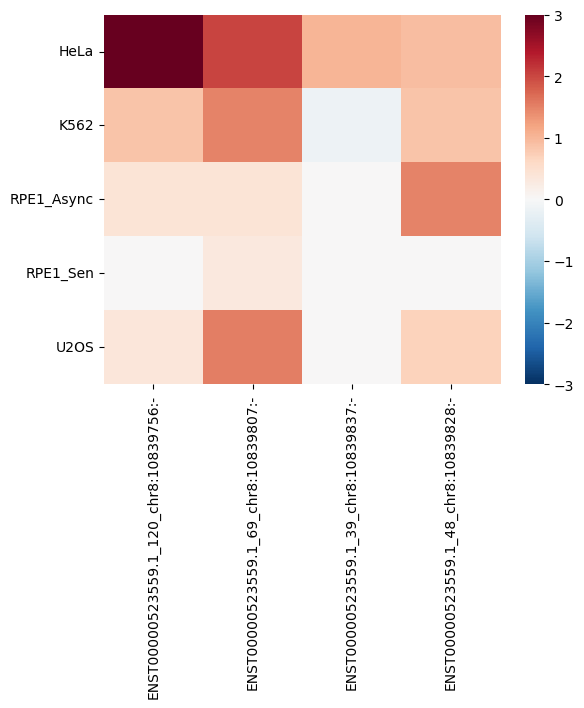

In [69]:
sns.heatmap(
    transcript_to_tis_vector[all_transcript_ids[3]].dropna(how='all').fillna(0), vmin=-3, vmax=3, cmap='RdBu_r'
)

<Axes: >

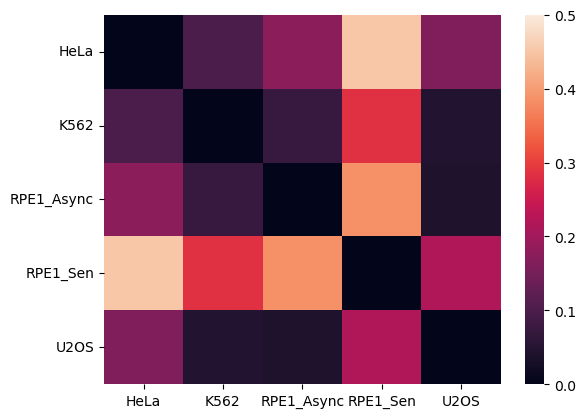

In [66]:
sns.heatmap(
    apply_pairwise(
        transcript_to_tis_vector[all_transcript_ids[3]].dropna(how='all').fillna(-np.inf),
        js_divergence, axis=0, symmetric=False
    ),
    vmin=0, vmax=0.5
)

In [13]:
gene_to_distance_matrix = dict()
for g in tqdm(all_gene_symbols):
    nonnull_matrix = gene_to_tis_vector[g].dropna(how='all').fillna(-np.inf)
    if nonnull_matrix.shape[0] > 1:
        gene_to_distance_matrix[g] = apply_pairwise(
            nonnull_matrix, js_divergence, axis=0, symmetric=True
        )

100%|██████████| 10990/10990 [03:33<00:00, 51.49it/s]


In [16]:
def symmetrize_matrix(mtx, diag_value=0):
    symm_mtx = np.maximum(mtx.fillna(0).values, mtx.T.fillna(0).values)
    np.fill_diagonal(symm_mtx, diag_value)
    return pd.DataFrame(symm_mtx, index=mtx.index, columns=mtx.columns)

In [ ]:
gene_average_pairwise_distance = dict()
gene_num_unique_tis = dict()
gene_num_samples_with_full_tis = dict()
gene_num_samples_with_half_tis = dict()
gene_num_samples_for_pairwise = dict()
for g in tqdm(gene_to_distance_matrix):
    gene_average_pairwise_distance[g] = np.nanmean(gene_to_distance_matrix[g].values.flatten())
    gene_num_unique_tis[g] = gene_to_tis_vector[g].shape[1]
    gene_num_samples_with_full_tis[g] = ((~(gene_to_tis_vector[g].isna())).sum(axis=1) == gene_to_tis_vector[g].shape[1]).sum()
    gene_num_samples_with_half_tis[g] = ((~(gene_to_tis_vector[g].isna())).sum(axis=1) >= (gene_to_tis_vector[g].shape[1] / 2)).sum()
    gene_num_samples_for_pairwise[g] = gene_to_distance_matrix[g].shape[0]
gene_average_pairwise_distance = pd.Series(gene_average_pairwise_distance, name='GeneMeanPairwiseTEVectorDifference')
gene_num_unique_tis = pd.Series(gene_num_unique_tis, name='GeneNumUniqueTIS')
gene_num_samples_with_full_tis = pd.Series(gene_num_samples_with_full_tis, name='GeneNumSamplesWithAllTIS')
gene_num_samples_with_half_tis = pd.Series(gene_num_samples_with_half_tis, name='GeneNumSamplesWithHalfTIS')
gene_num_samples_for_pairwise = pd.Series(gene_num_samples_for_pairwise, name='GeneNumSamplesWithAnyTIS')

gene_tis_vector_summary = pd.concat([
    gene_average_pairwise_distance, gene_num_unique_tis,
    gene_num_samples_with_full_tis, gene_num_samples_with_half_tis, gene_num_samples_for_pairwise], axis=1
).sort_values(['GeneNumSamplesWithHalfTIS', 'GeneNumUniqueTIS', 'GeneMeanPairwiseTEVectorDifference'], ascending=False).rename_axis('Symbol')

100%|██████████| 9369/9369 [00:12<00:00, 760.29it/s]


In [ ]:
gene_tis_annotations = []
for g in tqdm(gene_to_tis_vector):
    genome_starts = [':'.join(x.split(':')[:-1]) for x in gene_to_tis_vector[g].columns]
    tis_information = tis_metadata[tis_metadata['GenomeStart'].isin(genome_starts)]
    gene_tis_annotations.append(
        tis_information.groupby('RecatTISType')['GenomeStart'].nunique().reindex(index=['Annotated', 'Extended', 'Truncated', 'uORF']).fillna(0).astype(int).rename(g)
    )
gene_tis_annotations = pd.concat(gene_tis_annotations, axis=1).T
gene_tis_annotations = gene_tis_annotations.add_prefix('Num').add_suffix('Sites').reset_index(names=['Symbol']).set_index('Symbol')

In [161]:
gene_tis_vector_summary.merge(
    gene_tis_annotations, left_index=True, right_index=True
).to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/gene_tis_vector_difference_summary.csv')

In [63]:
transcript_to_distance_matrix = dict()
for t in tqdm(all_transcript_ids):
    nonnull_matrix = transcript_to_tis_vector[t].dropna(how='all').fillna(-np.inf)
    if nonnull_matrix.shape[0] > 1:
        transcript_to_distance_matrix[t] = apply_pairwise(
            nonnull_matrix, js_divergence, axis=0, symmetric=True
        )

100%|██████████| 43123/43123 [10:54<00:00, 65.85it/s]  


In [ ]:
transcript_average_pairwise_distance = dict()
transcript_num_unique_tis = dict()
transcript_num_samples_with_full_tis = dict()
transcript_num_samples_with_half_tis = dict()
transcript_num_samples_for_pairwise = dict()
for t in tqdm(transcript_to_distance_matrix):
    transcript_average_pairwise_distance[t] = np.nanmean(transcript_to_distance_matrix[t].values.flatten())
    transcript_num_unique_tis[t] = transcript_to_tis_vector[t].shape[1]
    transcript_num_samples_with_full_tis[t] = ((~(transcript_to_tis_vector[t].isna())).sum(axis=1) == transcript_to_tis_vector[t].shape[1]).sum()
    transcript_num_samples_with_half_tis[t] = ((~(transcript_to_tis_vector[t].isna())).sum(axis=1) >= (transcript_to_tis_vector[t].shape[1] / 2)).sum()
    transcript_num_samples_for_pairwise[t] = transcript_to_distance_matrix[t].shape[0]
transcript_average_pairwise_distance = pd.Series(transcript_average_pairwise_distance, name='TranscriptMeanPairwiseTEVectorDifference')
transcript_num_unique_tis = pd.Series(transcript_num_unique_tis, name='TranscriptNumUniqueTIS')
transcript_num_samples_with_full_tis = pd.Series(transcript_num_samples_with_full_tis, name='TranscriptNumSamplesWithAllTIS')
transcript_num_samples_with_half_tis = pd.Series(transcript_num_samples_with_half_tis, name='TranscriptNumSamplesWithHalfTIS')
transcript_num_samples_for_pairwise = pd.Series(transcript_num_samples_for_pairwise, name='TranscriptNumSamplesWithAnyTIS')

transcript_tis_vector_summary = pd.concat([
    transcript_average_pairwise_distance, transcript_num_unique_tis,
    transcript_num_samples_with_full_tis, transcript_num_samples_with_half_tis, transcript_num_samples_for_pairwise], axis=1
).sort_values(['TranscriptNumSamplesWithHalfTIS', 'TranscriptNumUniqueTIS', 'TranscriptMeanPairwiseTEVectorDifference'], ascending=False).rename_axis('Tid')

100%|██████████| 33969/33969 [00:46<00:00, 728.86it/s]


In [ ]:
transcript_tis_annotations = []
for t in tqdm(transcript_to_tis_vector):
    tis_information = tis_metadata[tis_metadata['TIS'].isin(transcript_to_tis_vector[t].columns)]
    transcript_tis_annotations.append(
        tis_information.groupby('RecatTISType')['TIS'].nunique().reindex(index=['Annotated', 'Extended', 'Truncated', 'uORF']).fillna(0).astype(int).rename(t)
    )
transcript_tis_annotations = pd.concat(transcript_tis_annotations, axis=1).T
transcript_tis_annotations = transcript_tis_annotations.add_prefix('Num').add_suffix('Sites').reset_index(names=['Tid']).set_index('Tid')

In [172]:
transcript_tis_vector_summary.merge(
    tis_metadata[['Tid', 'Symbol']].drop_duplicates(), left_index=True, right_on='Tid'
).set_index('Tid').merge(
    transcript_tis_annotations, left_index=True, right_index=True,
).to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/transcript_tis_vector_difference_summary.csv')

In [173]:
transcript_tis_vector_summary.merge(
    tis_metadata[['Tid', 'Symbol']].drop_duplicates(), left_index=True, right_on='Tid'
).set_index('Tid').merge(
    transcript_tis_annotations, left_index=True, right_index=True,
)

,TranscriptMeanPairwiseTEVectorDifference,TranscriptNumUniqueTIS,TranscriptNumSamplesWithAllTIS,TranscriptNumSamplesWithHalfTIS,TranscriptNumSamplesWithAnyTIS,Symbol,NumAnnotatedSites,NumExtendedSites,NumTruncatedSites,NumuORFSites
Tid,,,,,,,,,,
ENST00000581230.5,0.172892,11,0,6,6,DDX5,0,0,0,0
ENST00000578491.2,0.157154,11,0,6,6,DDX5,0,0,0,0
ENST00000225792.10,0.156297,11,0,6,6,DDX5,1,5,1,4
ENST00000585317.2,0.148354,11,0,6,6,DDX5,0,0,0,0
ENST00000579991.3,0.099583,11,0,6,6,DYNLL2,1,8,2,0
...,...,...,...,...,...,...,...,...,...,...
ENST00000562103.2,0.485203,3,0,0,5,ZNF598,1,0,2,0
ENST00000495265.5,0.485203,3,0,0,5,BRD9,0,0,0,3
ENST00000696125.1,0.415888,3,0,0,6,TBC1D5,1,0,0,2


### Standardize this analysis

In [4]:
def create_tis_vectors(te_matrix, sample_subset=None, tis_metadata_df=tis_metadata, level='Gene'):
    if sample_subset is None:
        sample_subset = te_matrix.columns.tolist()
    else:
        sample_subset = [s for s in sample_subset if s in te_matrix.columns.tolist()]

    annotated_te_matrix = te_matrix.fillna(0).merge(tis_metadata_df, left_index=True, right_on='TIS', how='left')
    annotated_te_matrix['GenomeStart'] = annotated_te_matrix['TIS'].str.split('_').str[-1]
    annotated_te_matrix['ChromosomePosition'] = annotated_te_matrix['GenomeStart'].str.split(':').str[1].astype(int)
    annotated_te_matrix['Orientation'] = annotated_te_matrix['GenomeStart'].str.split(':').str[-1]

    group_to_tis_vector = dict()
    gene_groups = annotated_te_matrix.groupby('Symbol').groups

    for gene_id, gene_subset_idxs in tqdm(gene_groups.items()):
        gene_subset = annotated_te_matrix.loc[gene_subset_idxs, :]
        if gene_subset.iloc[0].loc['Orientation'] == '+': # forward, use an ascending sort on the chromosome position
            sort_ascending = True
        else:
            sort_ascending = False
        gene_subset_ordered = gene_subset.sort_values('ChromosomePosition', ascending=sort_ascending)

        if level.lower() in ['gene', 'symbol']:
            average_log_te_vector = gene_subset_ordered.groupby('GenomeStart')[sample_subset].mean()
            group_to_tis_vector[gene_id] = average_log_te_vector.T
        elif level.lower() == 'transcript':
            for transcript_id, transcript_subset_idxs in gene_subset_ordered.groupby('Tid').groups.items():
                transcript_subset = gene_subset_ordered.loc[transcript_subset_idxs, :]
                group_to_tis_vector[transcript_id] = transcript_subset.set_index('TIS').loc[:, sample_subset].T
    return group_to_tis_vector


def convert_log_to_probs(vector, base=2):
    unlogged_vector = base ** vector
    probs = unlogged_vector / unlogged_vector.sum()
    return probs

from scipy.special import logsumexp
def js_divergence(log_P, log_Q, base=2):
    """
    Jensen-Shannon divergence, a symmetric measure of the difference between probability distributions
    JSD(P || Q) = 0.5 * KLD(P || M) + 0.5 * KLD(Q || M)
    M = 0.5 + (P + Q)
    logM = log(0.5) + log(P + Q) = log(P + Q) - log(2)
    """
    log_P = log_P.copy()
    log_Q = log_Q.copy()

    if base != np.e:
        # convert to natural log
        log_P = log_P * np.log(base)
        log_Q = log_Q * np.log(base)

    log_pP = log_P - logsumexp(log_P)
    log_pQ = log_Q - logsumexp(log_Q)

    log_mixture = np.logaddexp(log_pP, log_pQ) - np.log(2)

    pP = np.exp(log_pP)
    pQ = np.exp(log_pQ)

    KL_PvM = np.sum(pP * (log_pP - log_mixture))
    KL_QvM = np.sum(pQ * (log_pQ - log_mixture))

    return 0.5 * (KL_PvM + KL_QvM)

def apply_pairwise(df, func, axis=0, symmetric=True):
    df_copy = df.copy()
    if axis == 0:
        df_copy = df_copy.T
    elif axis != 1:
        raise ValueError('axis must be 0 or 1')
    elements = df_copy.columns.tolist()

    output = np.empty((len(elements), len(elements)))
    output.fill(np.nan)

    for i1 in range(len(elements)):
        if symmetric:
            other_range = range(i1+1, len(elements))
        else:
            other_range = range(len(elements))
        for i2 in other_range:
            output[i1, i2] = func(df_copy[elements[i1]], df_copy[elements[i2]])
    output_df = pd.DataFrame(output, index=elements, columns=elements)
    return output_df

def symmetrize_matrix(mtx, diag_value=0):
    symm_mtx = np.maximum(mtx.fillna(0).values, mtx.T.fillna(0).values)
    np.fill_diagonal(symm_mtx, diag_value)
    return pd.DataFrame(symm_mtx, index=mtx.index, columns=mtx.columns)


def summarize_vector_differences(group_to_vector_matrix, group_to_distance_matrix=None, group_type='Gene'):
    if group_to_distance_matrix is None:
        group_to_distance_matrix = dict()
        for g in tqdm(group_to_vector_matrix):
            nonnull_matrix = group_to_distance_matrix[g].dropna(how='all').fillna(-np.inf)
            if nonnull_matrix.shape[0] > 1:
                group_to_distance_matrix[g] = apply_pairwise(
                    nonnull_matrix, js_divergence, axis=0, symmetric=True
                )

    if group_type.lower() in ['gene', 'symbol']:
        column_prefix = 'Gene'
        index_name = 'Symbol'
    elif group_type.lower() == 'transcript':
        column_prefix = 'Transcript'
        index_name = 'Tid'
    
    group_vector_summary = {
        index_name: [],
        f'{column_prefix}MeanPairwiseTEVectorDifference': [],
        f'{column_prefix}NumUniqueTIS': [],
        f'{column_prefix}NumSamplesWithAllTIS': [],
        f'{column_prefix}NumSamplesWithHalfTIS': [],
        f'{column_prefix}NumSamplesWithAnyTIS': [],
    }

    for g in tqdm(group_to_distance_matrix):
        group_vector_summary[index_name].append(g)
        group_vector_summary[f'{column_prefix}MeanPairwiseTEVectorDifference'].append(np.nanmean(group_to_distance_matrix[g].values.flatten()))
        group_vector_summary[f'{column_prefix}NumUniqueTIS'].append(group_to_vector_matrix[g].shape[1])
        group_vector_summary[f'{column_prefix}NumSamplesWithAllTIS'].append(((~(group_to_vector_matrix[g].isna())).sum(axis=1) == group_to_vector_matrix[g].shape[1]).sum())
        group_vector_summary[f'{column_prefix}NumSamplesWithHalfTIS'].append(((~(group_to_vector_matrix[g].isna())).sum(axis=1) >= (group_to_vector_matrix[g].shape[1] / 2)).sum())
        group_vector_summary[f'{column_prefix}NumSamplesWithAnyTIS'].append(group_to_distance_matrix[g].shape[0])
    group_vector_summary = pd.DataFrame.from_dict(group_vector_summary).sort_values(
        by=[f'{column_prefix}NumSamplesWithHalfTIS', f'{column_prefix}NumUniqueTIS', f'{column_prefix}MeanPairwiseTEVectorDifference'], ascending=False
    )

    return group_to_distance_matrix, group_vector_summary

In [ ]:
gene_tis_annotations = []
for g in tqdm(gene_to_tis_vector):
    genome_starts = [':'.join(x.split(':')[:-1]) for x in gene_to_tis_vector[g].columns]
    tis_information = tis_metadata[tis_metadata['GenomeStart'].isin(genome_starts)]
    gene_tis_annotations.append(
        tis_information.groupby('RecatTISType')['GenomeStart'].nunique().reindex(index=['Annotated', 'Extended', 'Truncated', 'uORF']).fillna(0).astype(int).rename(g)
    )
gene_tis_annotations = pd.concat(gene_tis_annotations, axis=1).T
gene_tis_annotations = gene_tis_annotations.add_prefix('Num').add_suffix('Sites').reset_index(names=['Symbol']).set_index('Symbol')

  0%|          | 0/10990 [00:00<?, ?it/s]

100%|██████████| 10990/10990 [02:16<00:00, 80.23it/s]


In [144]:
transcript_tis_annotations = []
for t in tqdm(transcript_to_tis_vector):
    tis_information = tis_metadata[tis_metadata['TIS'].isin(transcript_to_tis_vector[t].columns)]
    transcript_tis_annotations.append(
        tis_information.groupby('RecatTISType')['TIS'].nunique().reindex(index=['Annotated', 'Extended', 'Truncated', 'uORF']).fillna(0).astype(int).rename(t)
    )
transcript_tis_annotations = pd.concat(transcript_tis_annotations, axis=1).T
transcript_tis_annotations = transcript_tis_annotations.add_prefix('Num').add_suffix('Sites').reset_index(names=['Tid']).set_index('Tid')

100%|██████████| 43123/43123 [08:46<00:00, 81.91it/s]


In [155]:
gene_tis_vector_summary.merge(gene_tis_annotations, left_index=True, right_index=True)

,GeneMeanPairwiseTEVectorDifference,GeneNumUniqueTIS,GeneNumSamplesWithAllTIS,GeneNumSamplesWithHalfTIS,GeneNumSamplesWithAnyTIS,NumAnnotatedSites,NumExtendedSites,NumTruncatedSites,NumuORFSites
DDX5,0.144754,13,0,6,6,2,5,2,4
CAPRIN1,0.109299,11,0,6,6,1,5,2,2
DYNLL2,0.099583,11,0,6,6,1,8,2,0
SPCS3,0.175601,10,0,6,6,1,3,2,2
QKI,0.156136,10,0,6,6,1,4,4,1
...,...,...,...,...,...,...,...,...,...
EPS8L2,0.508308,3,0,0,6,1,0,2,0
EPB41L1,0.485203,3,0,0,5,2,1,0,0
EXOC6B,0.485203,3,0,0,5,1,0,2,0
PDZD8,0.485203,3,0,0,5,1,0,0,2


<Axes: xlabel='GeneNumUniqueTIS', ylabel='GeneMeanPairwiseTEVectorDifference'>

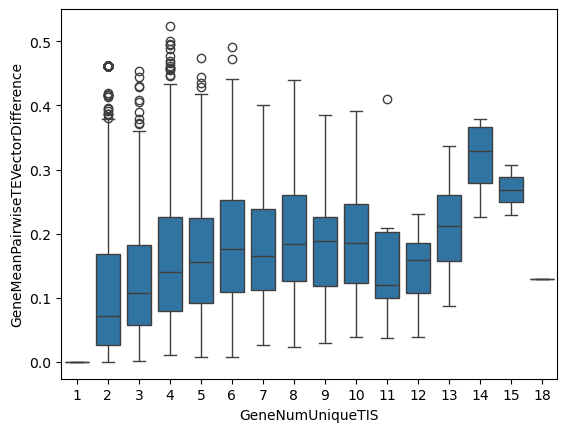

In [ ]:
sns.boxplot(
    gene_tis_vector_summary[gene_tis_vector_summary['GeneNumSamplesWithHalfTIS'] >= 3], 
    x='GeneNumUniqueTIS', y='GeneMeanPairwiseTEVectorDifference'
)

<Axes: xlabel='GeneNumUniqueTIS', ylabel='NormMeanVectorDiff'>

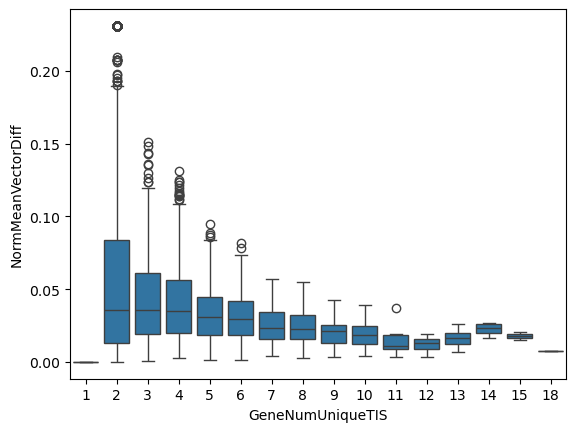

In [154]:
sns.boxplot(
    gene_tis_vector_summary[gene_tis_vector_summary['GeneNumSamplesWithHalfTIS'] >= 3].assign(
        NormMeanVectorDiff=lambda x: x['GeneMeanPairwiseTEVectorDifference'] / x['GeneNumUniqueTIS']
    ), 
    x='GeneNumUniqueTIS', y='NormMeanVectorDiff'
)

In [104]:
tis_metadata[tis_metadata['Symbol'] == 'MGA']

,TIS,Tid,Symbol,Gid,GeneType,GenomeStart,StartCodon,Start,RecatTISType,MANE_Select,AALen,AASeq
18120,ENST00000566586.6_196_chr15:41668894:+,ENST00000566586.6,MGA,ENSG00000174197.20,protein_coding,chr15:41668894,ATG,196.0,Annotated,False,2856.0,MEEKQQIILANQDGGTVAGAAPTFFVILKQPGNGKTDQGILVTNQD...
18121,ENST00000566586.6_5275_chr15:41749313:+,ENST00000566586.6,MGA,ENSG00000174197.20,protein_coding,chr15:41749313,AGG,5275.0,Truncated,False,1163.0,RISPPEPQSFASKTGSETKITYSSGGQPVGTASLIPLQSGSFALLQ...
18122,ENST00000566586.6_6184_chr15:41750222:+,ENST00000566586.6,MGA,ENSG00000174197.20,protein_coding,chr15:41750222,AAG,6184.0,Truncated,False,860.0,KTCQENSDVFQQEQGISDLLGKSGITEDARVLKTECDSWSRISNPS...
18123,ENST00000566288.1_400_chr15:41749313:+,ENST00000566288.1,MGA,ENSG00000174197.20,protein_coding,chr15:41749313,AGG,400.0,Other,False,441.0,RISPPEPQSFASKTGSETKITYSSGGQPVGTASLIPLQSGSFALLQ...
18124,ENST00000566288.1_1309_chr15:41750222:+,ENST00000566288.1,MGA,ENSG00000174197.20,protein_coding,chr15:41750222,AAG,1309.0,Other,False,138.0,KTCQENSDVFQQEQGISDLLGKSGITEDARVLKTECDSWSRISNPS...
...,...,...,...,...,...,...,...,...,...,...,...,...
412048,ENST00000703841.1_5693_chr15:41748782:+,ENST00000703841.1,MGA,ENSG00000174197.20,protein_coding,chr15:41748782,ATG,5693.0,Truncated,True,1279.0,MVLQPVRSPSGMNLFRHPNGQIVQLLPLHQLRGSNTQPNLQPVMFR...
412049,ENST00000703841.1_7193_chr15:41750465:+,ENST00000703841.1,MGA,ENSG00000174197.20,protein_coding,chr15:41750465,AAG,7193.0,Truncated,True,779.0,KKGGRSSADFTVLDLEEDDEDDNEKTDDSIDEIVDVVSDYQSEEVD...
412050,ENST00000564190.1_2800_chr15:41750465:+,ENST00000564190.1,MGA,ENSG00000174197.20,protein_coding,chr15:41750465,AAG,2800.0,Truncated,False,240.0,KKGGRSSADFTVLDLEEDDEDDNEKTDDSIDEIVDVVSDYQSEEVD...
428127,ENST00000566586.6_196_chr15:41668895:+,ENST00000566586.6,MGA,ENSG00000174197.20,protein_coding,chr15:41668895,ATG,196.0,Annotated,False,2856.0,MEEKQQIILANQDGGTVAGAAPTFFVILKQPGNGKTDQGILVTNQD...


In [ ]:
tis_metadata[tis_metadata['Symbol'] == 'CTNND1']

,TIS,Tid,Symbol,Gid,GeneType,StartCodon,Start,RecatTISType,MANE_Select,AALen,AASeq
13870,ENST00000524630.5_549_chr11:57791514:+,ENST00000524630.5,CTNND1,ENSG00000198561.17,protein_coding,TTG,549.0,Truncated,False,921.0,LASVKEQEAQFEKLTRALEEERRHVSAQLERVRVSPQDANPLMANG...
13871,ENST00000358694.10_499_chr11:57791514:+,ENST00000358694.10,CTNND1,ENSG00000198561.17,protein_coding,TTG,499.0,Truncated,False,921.0,LASVKEQEAQFEKLTRALEEERRHVSAQLERVRVSPQDANPLMANG...
13872,ENST00000361332.8_572_chr11:57791514:+,ENST00000361332.8,CTNND1,ENSG00000198561.17,protein_coding,TTG,572.0,Truncated,False,950.0,LASVKEQEAQFEKLTRALEEERRHVSAQLERVRVSPQDANPLMANG...
13873,ENST00000361391.10_572_chr11:57791514:+,ENST00000361391.10,CTNND1,ENSG00000198561.17,protein_coding,TTG,572.0,Truncated,False,929.0,LASVKEQEAQFEKLTRALEEERRHVSAQLERVRVSPQDANPLMANG...
13874,ENST00000361796.9_572_chr11:57791514:+,ENST00000361796.9,CTNND1,ENSG00000198561.17,protein_coding,TTG,572.0,Truncated,False,927.0,LASVKEQEAQFEKLTRALEEERRHVSAQLERVRVSPQDANPLMANG...
...,...,...,...,...,...,...,...,...,...,...,...
384435,ENST00000528232.5_358_chr11:57795613:+,ENST00000528232.5,CTNND1,ENSG00000198561.17,protein_coding,ATG,358.0,Annotated,False,838.0,MQEPGQIVETYTEEDPEGAMSVVSVETSDDGTTRRTETTVKKVVKT...
384439,ENST00000529986.5_358_chr11:57795613:+,ENST00000529986.5,CTNND1,ENSG00000198561.17,protein_coding,ATG,358.0,Annotated,False,832.0,MQEPGQIVETYTEEDPEGAMSVVSVETSDDGTTRRTETTVKKVVKT...
384440,ENST00000530094.5_358_chr11:57795613:+,ENST00000530094.5,CTNND1,ENSG00000198561.17,protein_coding,ATG,358.0,Annotated,False,861.0,MQEPGQIVETYTEEDPEGAMSVVSVETSDDGTTRRTETTVKKVVKT...
384443,ENST00000532245.5_286_chr11:57795613:+,ENST00000532245.5,CTNND1,ENSG00000198561.17,protein_coding,ATG,286.0,Annotated,False,832.0,MQEPGQIVETYTEEDPEGAMSVVSVETSDDGTTRRTETTVKKVVKT...


In [88]:
summarize_vector_differences(gene_to_tis_vector, gene_to_distance_matrix, group_type='Gene')

100%|██████████| 9369/9369 [00:12<00:00, 758.74it/s]


,Symbol,GeneMeanPairwiseTEVectorDifference,GeneNumUniqueTIS,GeneNumSamplesWithAllTIS,GeneNumSamplesWithHalfTIS,GeneNumSamplesWithAnyTIS
2112,DDX5,0.144754,13,0,6,6
2854,CAPRIN1,0.109299,11,0,6,6
5308,DYNLL2,0.099583,11,0,6,6
4180,SPCS3,0.175601,10,0,6,6
5813,QKI,0.156136,10,0,6,6
...,...,...,...,...,...,...
7304,EPS8L2,0.508308,3,0,0,6
4609,EPB41L1,0.485203,3,0,0,5
5134,EXOC6B,0.485203,3,0,0,5
6452,PDZD8,0.485203,3,0,0,5


## TODO: redo this analysis for sample subsets (cell lines, RPE1-only)

In [100]:
from scripts.analysis_pipelines import *

## Cell lines

In [5]:
te_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/cell_lines/translation_efficiency_vst_matrix.csv', index_col=0)

In [11]:
gene_to_tis_vector = create_tis_vectors(
    te_matrix[tis_mask.reindex_like(te_matrix) & rna_mask.reindex_like(te_matrix)],
    tis_metadata, sample_subset=['HeLa', 'K562', 'RPE1_Async', 'U2OS'], level='Gene'
)
transcript_to_tis_vector = create_tis_vectors(
    te_matrix[tis_mask.reindex_like(te_matrix) & rna_mask.reindex_like(te_matrix)],
    tis_metadata, sample_subset=['HeLa', 'K562', 'RPE1_Async', 'U2OS'], level='Transcript'
)

100%|██████████| 12174/12174 [02:50<00:00, 71.52it/s] 


In [15]:
encode_tis_vector_df(gene_to_tis_vector).to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/cell_lines/gene_tis_vector_logte_table.csv', index=False)
encode_tis_vector_df(transcript_to_tis_vector).to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/cell_lines/transcript_tis_vector_logte_table.csv', index=False)

  0%|          | 0/12174 [00:00<?, ?it/s]

100%|██████████| 50918/50918 [03:30<00:00, 242.44it/s]


In [16]:
gene_tis_table = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/cell_lines/gene_tis_vector_logte_table.csv')
transcript_tis_table = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/cell_lines/transcript_tis_vector_logte_table.csv')

In [17]:
gene_to_tis_vector = parse_tis_table(gene_tis_table, mask_zeroes=True)
transcript_to_tis_vector = parse_tis_table(transcript_tis_table, mask_zeroes=True)

100%|██████████| 50918/50918 [02:39<00:00, 319.56it/s]


In [21]:
gene_to_distance_matrix, gene_tis_vector_summary = summarize_vector_differences(gene_to_tis_vector, group_type='Gene')
transcript_to_distance_matrix, transcript_tis_vector_summary = summarize_vector_differences(transcript_to_tis_vector, group_type='Transcript')

100%|██████████| 31700/31700 [00:49<00:00, 643.71it/s]


In [55]:
gene_tis_annotations = create_tis_annotations(gene_to_tis_vector, tis_metadata, group_type='Gene')

100%|██████████| 12174/12174 [02:38<00:00, 76.62it/s]


In [57]:
transcript_tis_annotations = create_tis_annotations(transcript_to_tis_vector, tis_metadata, group_type='Transcript')

100%|██████████| 50918/50918 [12:29<00:00, 67.97it/s]


In [ ]:
gene_tis_vector_summary.merge(gene_tis_annotations, left_index=True, right_index=True, how='left').to_csv(
    '/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/cell_lines/gene_tis_vector_difference_summary.csv'
)
transcript_tis_vector_summary.merge(transcript_tis_annotations, left_index=True, right_index=True, how='left').to_csv(
    '/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/cell_lines/transcript_tis_vector_difference_summary.csv'
)

## RPE1

In [60]:
te_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/translation_efficiency_vst_matrix.csv', index_col=0)

In [61]:
gene_to_tis_vector = create_tis_vectors(
    te_matrix[tis_mask.reindex_like(te_matrix) & rna_mask.reindex_like(te_matrix)],
    tis_metadata, sample_subset=['RPE1_Async', 'RPE1_Que', 'RPE1_Sen'], level='Gene'
)
transcript_to_tis_vector = create_tis_vectors(
    te_matrix[tis_mask.reindex_like(te_matrix) & rna_mask.reindex_like(te_matrix)],
    tis_metadata, sample_subset=['RPE1_Async', 'RPE1_Que', 'RPE1_Sen'], level='Transcript'
)

100%|██████████| 9843/9843 [01:53<00:00, 86.87it/s] 


In [62]:
encode_tis_vector_df(gene_to_tis_vector).to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/gene_tis_vector_logte_table.csv', index=False)
encode_tis_vector_df(transcript_to_tis_vector).to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/transcript_tis_vector_logte_table.csv', index=False)

100%|██████████| 35312/35312 [02:05<00:00, 280.95it/s]


In [63]:
gene_tis_table = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/gene_tis_vector_logte_table.csv')
transcript_tis_table = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/transcript_tis_vector_logte_table.csv')

In [64]:
gene_to_tis_vector = parse_tis_table(gene_tis_table, mask_zeroes=True)
transcript_to_tis_vector = parse_tis_table(transcript_tis_table, mask_zeroes=True)

100%|██████████| 35312/35312 [01:38<00:00, 359.76it/s]


In [65]:
gene_to_distance_matrix, gene_tis_vector_summary = summarize_vector_differences(gene_to_tis_vector, group_type='Gene')
transcript_to_distance_matrix, transcript_tis_vector_summary = summarize_vector_differences(transcript_to_tis_vector, group_type='Transcript')

100%|██████████| 19498/19498 [00:28<00:00, 691.03it/s]


In [66]:
gene_tis_annotations = create_tis_annotations(gene_to_tis_vector, tis_metadata, group_type='Gene')
transcript_tis_annotations = create_tis_annotations(transcript_to_tis_vector, tis_metadata, group_type='Transcript')

100%|██████████| 35312/35312 [07:47<00:00, 75.60it/s]


In [67]:
gene_tis_vector_summary.merge(gene_tis_annotations, left_index=True, right_index=True, how='left').to_csv(
    '/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/gene_tis_vector_difference_summary.csv'
)
transcript_tis_vector_summary.merge(transcript_tis_annotations, left_index=True, right_index=True, how='left').to_csv(
    '/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/transcript_tis_vector_difference_summary.csv'
)

## Analyze the subset-specific results

In [68]:
rpe1_gene_tis_vector_summary = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/gene_tis_vector_difference_summary.csv')
rpe1_transcript_tis_vector_summary = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/transcript_tis_vector_difference_summary.csv')

<Axes: xlabel='GeneNumUniqueTIS', ylabel='GeneMeanPairwiseTEVectorDifference'>

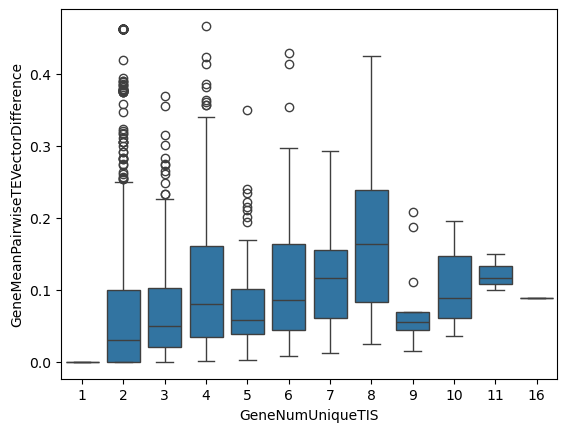

In [ ]:
sns.boxplot(
    rpe1_gene_tis_vector_summary[rpe1_gene_tis_vector_summary['GeneNumSamplesWithHalfTIS'] >= 3], 
    x='GeneNumUniqueTIS', y='GeneMeanPairwiseTEVectorDifference'
)

<Axes: xlabel='GeneNumUniqueTIS', ylabel='GeneMeanPairwiseTEVectorDifference'>

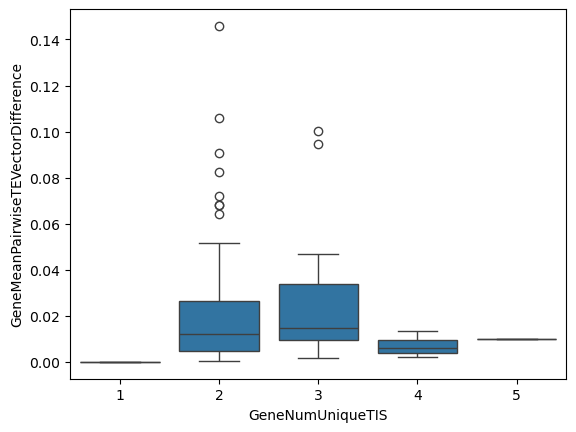

In [70]:
sns.boxplot(
    rpe1_gene_tis_vector_summary[rpe1_gene_tis_vector_summary['GeneNumSamplesWithAllTIS'] >= 3], 
    x='GeneNumUniqueTIS', y='GeneMeanPairwiseTEVectorDifference'
)

<Axes: xlabel='TranscriptNumUniqueTIS', ylabel='TranscriptMeanPairwiseTEVectorDifference'>

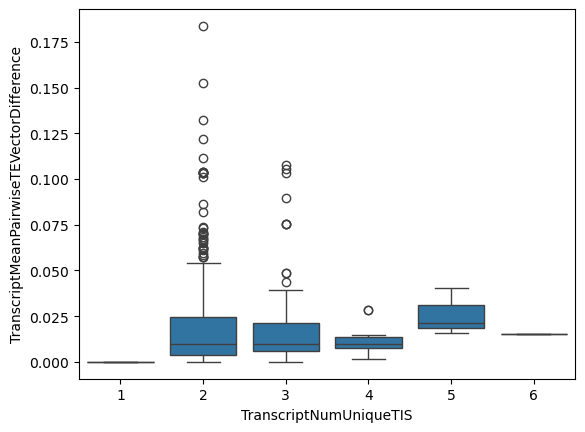

In [73]:
sns.boxplot(
    rpe1_transcript_tis_vector_summary[rpe1_transcript_tis_vector_summary['TranscriptNumSamplesWithAllTIS'] >= 3], 
    x='TranscriptNumUniqueTIS', y='TranscriptMeanPairwiseTEVectorDifference'
)

In [74]:
cell_line_gene_tis_vector_summary = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/cell_lines/gene_tis_vector_difference_summary.csv')
cell_line_transcript_tis_vector_summary = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/cell_lines/transcript_tis_vector_difference_summary.csv')

<Axes: xlabel='GeneNumUniqueTIS', ylabel='GeneMeanPairwiseTEVectorDifference'>

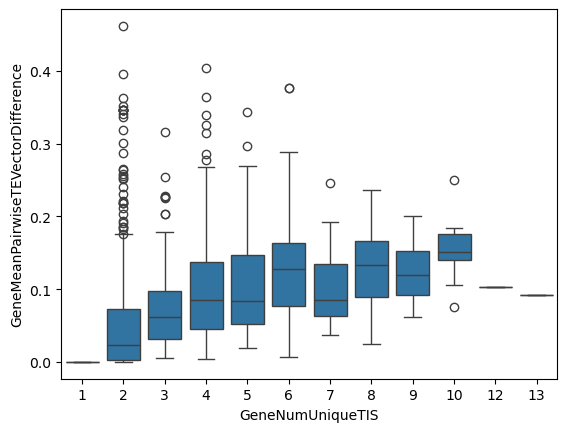

In [76]:
sns.boxplot(
    cell_line_gene_tis_vector_summary[cell_line_gene_tis_vector_summary['GeneNumSamplesWithHalfTIS'] >= 4], 
    x='GeneNumUniqueTIS', y='GeneMeanPairwiseTEVectorDifference'
)

<Axes: xlabel='TranscriptNumUniqueTIS', ylabel='TranscriptMeanPairwiseTEVectorDifference'>

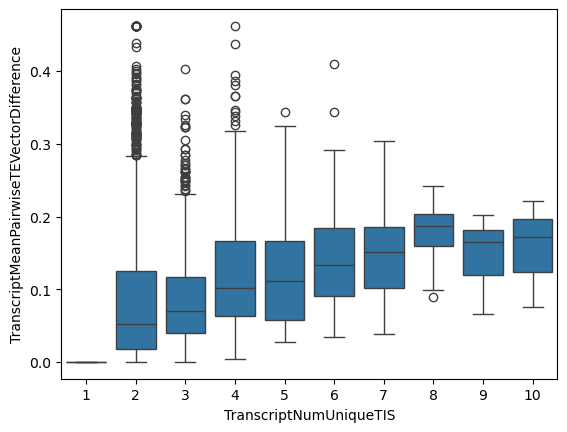

In [78]:
sns.boxplot(
    cell_line_transcript_tis_vector_summary[cell_line_transcript_tis_vector_summary['TranscriptNumSamplesWithHalfTIS'] >= 4], 
    x='TranscriptNumUniqueTIS', y='TranscriptMeanPairwiseTEVectorDifference'
)

In [92]:
mane_select_transcript_ids = tis_metadata[tis_metadata['MANE_Select']]['Tid'].tolist()

Text(0.5, 1.0, 'Across RPE1 cell states')

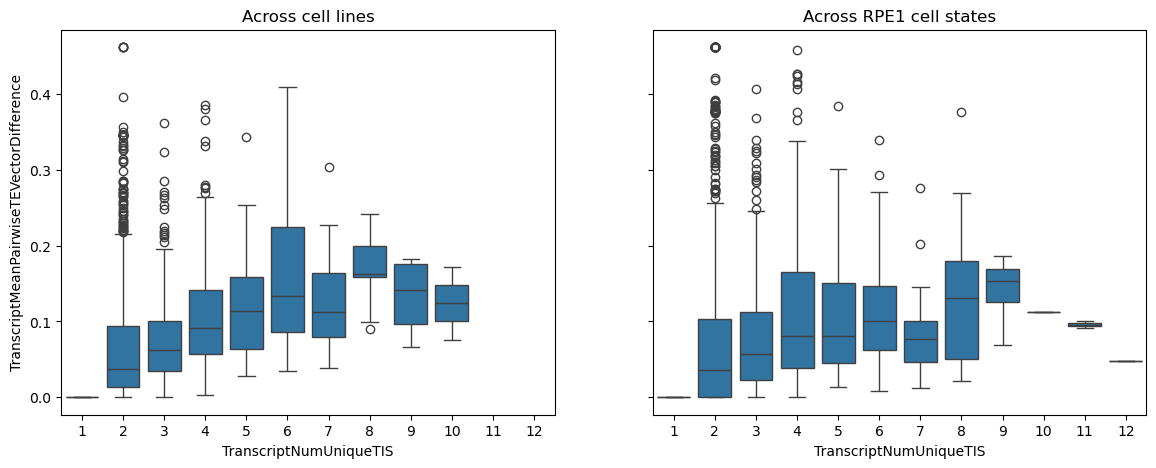

In [94]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

sns.boxplot(
    cell_line_transcript_tis_vector_summary[
        (cell_line_transcript_tis_vector_summary['TranscriptNumSamplesWithHalfTIS'] >= 4) &
        (cell_line_transcript_tis_vector_summary['Tid'].isin(mane_select_transcript_ids))
    ], 
    x='TranscriptNumUniqueTIS', y='TranscriptMeanPairwiseTEVectorDifference', ax=axs[0]
)
axs[0].set_title('Across cell lines')

sns.boxplot(
    rpe1_transcript_tis_vector_summary[
        (rpe1_transcript_tis_vector_summary['TranscriptNumSamplesWithHalfTIS'] >= 3) &
        (rpe1_transcript_tis_vector_summary['Tid'].isin(mane_select_transcript_ids))
    ], 
    x='TranscriptNumUniqueTIS', y='TranscriptMeanPairwiseTEVectorDifference', ax=axs[1]
)
axs[1].set_title('Across RPE1 cell states')

In [95]:
rpe1_transcript_tis_vector_summary[
    (rpe1_transcript_tis_vector_summary['TranscriptNumUniqueTIS'] == 8) & 
    (rpe1_transcript_tis_vector_summary['TranscriptNumSamplesWithHalfTIS'] >= 3)
].sort_values(
    'TranscriptMeanPairwiseTEVectorDifference', ascending=False
)

,Tid,TranscriptMeanPairwiseTEVectorDifference,TranscriptNumUniqueTIS,TranscriptNumSamplesWithAllTIS,TranscriptNumSamplesWithHalfTIS,TranscriptNumSamplesWithAnyTIS,StartCodons,InterTISDistances,UTRLengths,NumAnnotatedSites,NumExtendedSites,NumTruncatedSites,NumuORFSites
18,ENST00000438032.6,0.377063,8,0,3,3,CTG|GTG|CTG|GTG|ATG|AAG|ATG|ATA,57|6709|24|59|39|508|3151,18|75|130|154|213|252|327|417,1,0,3,4
19,ENST00000249883.10,0.270189,8,0,3,3,CTG|TTG|GTG|CTG|GTG|AGG|CTG|ATG,22|5|13|2885|19|6|21,43|65|70|83|121|140|146|167,1,4,0,3
20,ENST00000357797.9,0.205185,8,0,3,3,ATT|ATC|ACG|CTG|CTG|ACG|GTG|AGG,3|61|60|126|36|30|18,56|59|120|180|306|342|372|390,0,6,0,2
21,ENST00000370094.7,0.196503,8,0,3,3,ATT|ATC|ACG|CTG|CTG|ACG|GTG|AGG,3|61|60|126|36|30|18,56|59|120|180|306|342|372|390,0,6,0,2
22,ENST00000526691.5,0.184738,8,0,3,3,ATT|ATT|ATG|ATG|CTG|CTG|ATG|AAG,45|116|181|1608|39|22342|24,114|159|275|456|480|519|612|636,1,0,4,3
23,ENST00000377534.8,0.181669,8,0,3,3,CTG|CTG|TTG|ACG|CTG|ATG|GTG|AAG,27|29|64|5|169|36|182822,34|61|90|154|159|328|364|2515,1,3,2,2
24,ENST00000611266.4,0.180082,8,0,3,3,ATT|TTG|CTG|ACG|TTG|CTG|ATG|ACG,48|167|9|90|15|71862|36643,67|115|282|291|381|396|480|639,0,5,1,2
25,ENST00000261183.8,0.180082,8,0,3,3,ATT|TTG|CTG|ACG|TTG|CTG|ATG|ACG,48|167|9|90|15|71862|36643,29|77|244|253|343|358|442|601,1,4,1,2
26,ENST00000269576.6,0.169939,8,0,3,3,ACG|ACG|GTG|ACG|ACG|ATT|ATG|ATG,27|30|30|45|412|42|85,1566|1593|1623|1653|1698|1806|1848|1933,0,0,0,0
27,ENST00000272542.8,0.158721,8,1,3,3,GTG|GTG|CTG|CTG|ATG|ATG|ATG|ATT,53|15|93|466|236|12770|3364,27|80|95|188|221|457|1900|2434,1,0,2,5


In [96]:
tis_metadata[(tis_metadata['Tid'] == 'ENST00000438032.6')].sort_values('Start')

,TIS,Tid,Symbol,Gid,GeneType,GenomeStart,StartCodon,Start,RecatTISType,MANE_Select,AALen,AASeq
251671,ENST00000438032.6_18_chr1:20787289:-,ENST00000438032.6,HP1BP3,ENSG00000127483.21,protein_coding,chr1:20787289,CTG,18.0,uORF,True,9.0,LEDSGGGGD*
306894,ENST00000438032.6_75_chr1:20787232:-,ENST00000438032.6,HP1BP3,ENSG00000127483.21,protein_coding,chr1:20787232,GTG,75.0,uORF,True,28.0,VRDAGARTGRTQRLILHHTETIRKNPCG*
306895,ENST00000438032.6_130_chr1:20780523:-,ENST00000438032.6,HP1BP3,ENSG00000127483.21,protein_coding,chr1:20780523,CTG,130.0,uORF,True,17.0,LKPLGKILVVNSRGFRV*
220065,ENST00000438032.6_154_chr1:20780499:-,ENST00000438032.6,HP1BP3,ENSG00000127483.21,protein_coding,chr1:20780499,GTG,154.0,uORF,True,9.0,VVNSRGFRV*
285,ENST00000438032.6_213_chr1:20780440:-,ENST00000438032.6,HP1BP3,ENSG00000127483.21,protein_coding,chr1:20780440,ATG,213.0,Annotated,True,553.0,MATDTSQGELVHPKALPLIVGAQLIHADKLGEKVEDSTMPIRRTVN...
286,ENST00000438032.6_252_chr1:20780401:-,ENST00000438032.6,HP1BP3,ENSG00000127483.21,protein_coding,chr1:20780401,AAG,252.0,Truncated,True,540.0,KALPLIVGAQLIHADKLGEKVEDSTMPIRRTVNSTRETPPKSKLAE...
287,ENST00000438032.6_327_chr1:20779893:-,ENST00000438032.6,HP1BP3,ENSG00000127483.21,protein_coding,chr1:20779893,ATG,327.0,Truncated,True,515.0,MPIRRTVNSTRETPPKSKLAEGEEEKPEPDISSEESVSTVEEQENE...
220064,ENST00000438032.6_417_chr1:20776742:-,ENST00000438032.6,HP1BP3,ENSG00000127483.21,protein_coding,chr1:20776742,ATA,417.0,Truncated,True,485.0,ISSEESVSTVEEQENETPPATSSEAEQPKGEPENEEKEENKSSEET...
388346,ENST00000438032.6_750_chr1:20771046:-,ENST00000438032.6,HP1BP3,ENSG00000127483.21,protein_coding,chr1:20771046,GTG,750.0,Truncated,True,374.0,VVAIRKYIIHKYPSLELERRGYLLKQALKRELNRGVIKQVKGKGAS...
388347,ENST00000438032.6_1236_chr1:20749840:-,ENST00000438032.6,HP1BP3,ENSG00000127483.21,protein_coding,chr1:20749840,ATG,1236.0,Truncated,True,212.0,MEYAILSAIAAMNEPKTCSTTALKKYVLENHPGTNSNYQMHLLKKT...


# Pairwise comparisons

## RPE1 altered cell state vs. asynchronous

In [ ]:
from scripts.analysis_pipelines import *

from gseapy import Msigdb
import gseapy as gp
msig = Msigdb()

In [102]:
rpe1_samples = ['RPE1_Async', 'RPE1_Que', 'RPE1_Sen']

rpe1_pairwise_wald_tests = dict()
for f in os.listdir('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/pairwise_wald'):
    sample_match = re.search('(.+)_vs_(.+).csv', f)
    s1, s2 = sample_match.groups()
    rpe1_pairwise_wald_tests[(s1, s2)] = pd.read_csv(f'/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/pairwise_wald/{f}', index_col=0)

rpe1_tis_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/translation_efficiency_vst_matrix.csv', index_col=0)
rpe1_tis_matrix = rpe1_tis_matrix[tis_mask.reindex_like(rpe1_tis_matrix) & rna_mask.reindex_like(rpe1_tis_matrix)]

rpe1_lfc_block = extract_TIS_block(comparison_metric='log2FoldChange', pairwise_dict=rpe1_pairwise_wald_tests, masked_tis_matrix=rpe1_tis_matrix)
rpe1_qval_block = extract_TIS_block(comparison_metric='padj', pairwise_dict=rpe1_pairwise_wald_tests, masked_tis_matrix=rpe1_tis_matrix)

100%|██████████| 3/3 [00:00<00:00, 13.49it/s]


In [114]:
rpe1_pairwise_wald_rna_tests = dict()
for f in os.listdir('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/pairwise_wald_rna'):
    sample_match = re.search('(.+)_vs_(.+).csv', f)
    s1, s2 = sample_match.groups()
    rpe1_pairwise_wald_rna_tests[(s1, s2)] = pd.read_csv(f'/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/RPE1_states/pairwise_wald_rna/{f}', index_col=0)

In [119]:
que_vs_async_rna = rpe1_pairwise_wald_rna_tests[('RPE1_Que', 'RPE1_Async')].merge(
    tis_metadata[['Gid', 'Symbol']].drop_duplicates(), left_index=True, right_on='Gid', how='left'
)

In [120]:
que_vs_async_tis = rpe1_pairwise_wald_tests[('RPE1_Que', 'RPE1_Async')].merge(
    tis_metadata, left_index=True, right_on='TIS', how='left'
)

In [129]:
def plot_volcano(df, x='log2FoldChange', y='padj', transform_y=lambda x: -np.log10(x), min_x=1, max_p=0.05, **plt_kws):
    plot_df = df.copy()
    plot_df['x'] = plot_df[x]
    
    if transform_y is None:
        transform_y = lambda x: x
    plot_df['y'] = transform_y(plot_df[y])
    hline = transform_y(max_p)

    plot_df['highlight'] = (plot_df['x'].abs() > min_x) & (plot_df['y'] > hline)

    sns.scatterplot(plot_df, x='x', y='y', hue='highlight', palette={True: 'tab:blue', False: 'tab:gray'}, **plt_kws)
    plt.gca().axhline(hline, color='red', linestyle='dotted', alpha=0.5)
    plt.gca().axvline(-min_x, color='red', linestyle='dotted', alpha=0.5)
    plt.gca().axvline(min_x, color='red', linestyle='dotted', alpha=0.5)
    return plt.gca()


Text(0.5, 1.0, 'RNAseq')

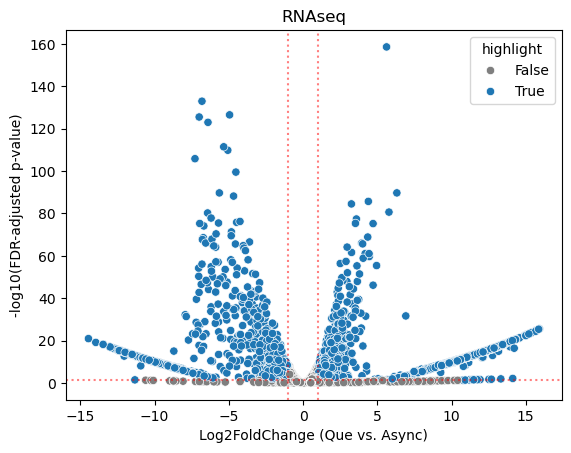

In [135]:
plot_volcano(que_vs_async_rna)
plt.xlabel('Log2FoldChange (Que vs. Async)')
plt.ylabel('-log10(FDR-adjusted p-value)')
plt.title('RNAseq')

Text(0.5, 1.0, 'Riboseq')

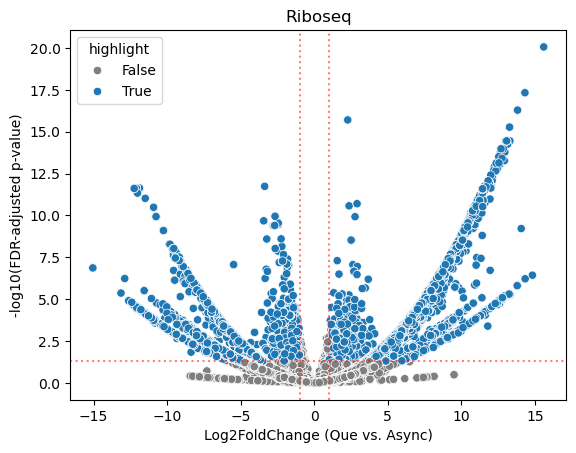

In [136]:
plot_volcano(que_vs_async_tis)
plt.xlabel('Log2FoldChange (Que vs. Async)')
plt.ylabel('-log10(FDR-adjusted p-value)')
plt.title('Riboseq')

In [146]:
que_vs_async_tis.sort_values('padj')

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,TIS,Tid,Symbol,Gid,GeneType,GenomeStart,StartCodon,Start,RecatTISType,MANE_Select,AALen,AASeq
111278,1069.597022,15.596125,1.490587,10.463074,1.276466e-25,8.642569e-21,ENST00000561491.1_50_chr16:56608655:+,ENST00000561491.1,MT2A,ENSG00000125148.8,protein_coding,chr16:56608655,ATG,50.0,Annotated,False,73.0,MDPNCSCAAGDSCTCAGSCKCKECKCTSCKKSKWDPLFPLPLPCPP...
140086,3898.232793,14.317366,1.464124,9.778791,1.388588e-22,4.700855e-18,ENST00000486051.5_118_chr1:8874908:-,ENST00000486051.5,ENO1,ENSG00000074800.17,protein_coding,chr1:8874908,ATG,118.0,Other,False,123.0,MSILKIHAREIFDSRGNPTVEVDLFTSKGLFRAAVPSGASTGIYEA...
261706,6046.615231,13.816121,1.460246,9.461503,3.035488e-21,5.138095e-17,ENST00000514924.5_271_chr4:41256976:+,ENST00000514924.5,UCHL1,ENSG00000154277.14,protein_coding,chr4:41256976,ATG,271.0,Annotated,False,58.0,MQLKPMEINPEMLNKVLSRLGVAGQWRFVDVLGLEEESLGSVPAPA...
261711,6046.615231,13.816121,1.460246,9.461503,3.035488e-21,5.138095e-17,ENST00000512788.1_32_chr4:41256976:+,ENST00000512788.1,UCHL1,ENSG00000154277.14,protein_coding,chr4:41256976,ATG,32.0,Annotated,False,241.0,MQLKPMEINPEMLNKVLSRLGVAGQWRFVDVLGLEEESLGSVPAPA...
129962,569.030265,2.272047,0.244417,9.295796,1.461084e-20,1.978513e-16,ENST00000480592.6_91_chrX:41334252:+,ENST00000480592.6,DDX3X,ENSG00000215301.12,protein_coding,chrX:41334252,ATG,91.0,Other,False,43.0,MSHVAVENALGLDQQFAGLDLNSSDNQSGGSTASSKYNILWVY*
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229480,25.808019,-0.000295,0.870249,-0.000339,9.997297e-01,9.997887e-01,ENST00000297145.9_71_chr7:112939804:-,ENST00000297145.9,SAMTOR,ENSG00000164603.13,protein_coding,chr7:112939804,CTG,71.0,Extended,True,423.0,LGSVCGGLRGGGGGGGCDMEPGAGGRNTARAQRAGSPNTPPPREQE...
9410,46.524136,-0.000209,0.728005,-0.000287,9.997711e-01,9.998006e-01,ENST00000541970.6_56_chr6:170584581:-,ENST00000541970.6,PDCD2,ENSG00000071994.11,protein_coding,chr6:170584581,ATG,56.0,Annotated,True,344.0,MAAAGARPVELGFAESAPAWRLRSEQFPSKVGGRPAWLGAAGLPGP...
9413,46.524136,-0.000209,0.728005,-0.000287,9.997711e-01,9.998006e-01,ENST00000542896.5_31_chr6:170584581:-,ENST00000542896.5,PDCD2,ENSG00000071994.11,protein_coding,chr6:170584581,ATG,31.0,Annotated,False,298.0,MAAAGARPVELGFAESAPAWRLRSEQFPSKVGGRPAWLGAAGLPGP...
191324,24.969837,-0.000506,2.078840,-0.000244,9.998057e-01,9.998057e-01,ENST00000563498.1_228_chr16:1771333:-,ENST00000563498.1,NME3,ENSG00000103024.9,protein_coding,chr16:1771333,GTG,228.0,Extended,False,128.0,VRRFERKGFKLVALKLVQASEELLREHYAELRERPFYGRLVKYMAS...


In [177]:
# take significant rna changes and significant TIS changes and intersect them
def merge_tis_and_rna_deseqs(tis_df, rna_df, 
                             min_tis_effect=1, min_rna_effect=1, 
                             max_tis_p=0.05, max_rna_p=0.05, 
                             effect_column='log2FoldChange', p_column='padj'):
    significant_tis_df = tis_df.copy()
    top_tis_per_gene = significant_tis_df[
        significant_tis_df['RecatTISType'] == 'Annotated' # presumably if any of the annotated TISs shifts, a non-canonical one must compensate
    ].groupby('Gid')[p_column].idxmin()
    consolidated_significant_tis_df = significant_tis_df.loc[
        top_tis_per_gene, :
    ]
    consolidated_significant_tis_df['SigRibo'] = (
        (consolidated_significant_tis_df[effect_column].abs() > min_tis_effect) &
        (consolidated_significant_tis_df[p_column].abs() < max_tis_p)
    )

    significant_rna_df = rna_df.copy()
    significant_rna_df['SigRNA'] = (
        (significant_rna_df[effect_column].abs() > min_rna_effect) &
        (significant_rna_df[p_column].abs() < max_rna_p)
    )

    add_prefix = lambda x, c: x + '_' + c

    merged = consolidated_significant_tis_df[['TIS', effect_column, p_column, 'lfcSE', 'Symbol', 'SigRibo']].rename(
        {c: add_prefix('Ribo', c) for c in [effect_column, p_column, 'lfcSE']}, axis=1
    ).merge(
        significant_rna_df[[effect_column, p_column, 'lfcSE', 'Symbol', 'SigRNA']].rename(
            {c: add_prefix('RNA', c) for c in [effect_column, p_column, 'lfcSE']}, axis=1
        ), left_on=['Symbol'], right_on=['Symbol'], how='inner'
    )

    return merged

In [192]:
def plot_cross_scatter(merged_tis_rna_df, max_lfc_se = 1):
    plot_df = merged_tis_rna_df.copy()

    plot_df.loc[:, 'Significant'] = 'Neither'
    plot_df.loc[plot_df['SigRibo'], 'Significant'] = 'Ribo'
    plot_df.loc[plot_df['SigRNA'], 'Significant'] = 'RNA'
    plot_df.loc[plot_df['SigRibo'] & plot_df['SigRNA'], 'Significant'] = 'Both'

    filtered_plot_df = plot_df[
        (plot_df['Ribo_lfcSE'] < max_lfc_se) &
        (plot_df['RNA_lfcSE'] < max_lfc_se)
    ]

    sns.scatterplot(
        filtered_plot_df[filtered_plot_df['Significant'] == 'Neither'],
        x='RNA_log2FoldChange', y='Ribo_log2FoldChange', 
        color='tab:gray', alpha=0.5, size=2, legend=False
    )
    sns.scatterplot(
        filtered_plot_df[filtered_plot_df['Significant'] != 'Neither'], 
        x='RNA_log2FoldChange', y='Ribo_log2FoldChange', 
        hue='Significant', palette={'Ribo': 'tab:blue', 'RNA': 'tab:red', 'Both': 'tab:purple'}
    )
    plt.gca().axhline(0, color='black', linestyle='dashed', alpha=0.5)
    plt.gca().axvline(0, color='black', linestyle='dashed', alpha=0.5)
    return plt.gca(), filtered_plot_df

Text(0.5, 1.0, 'RPE1 Quiescent vs. Asynchronous\nChange in translation vs transcription')

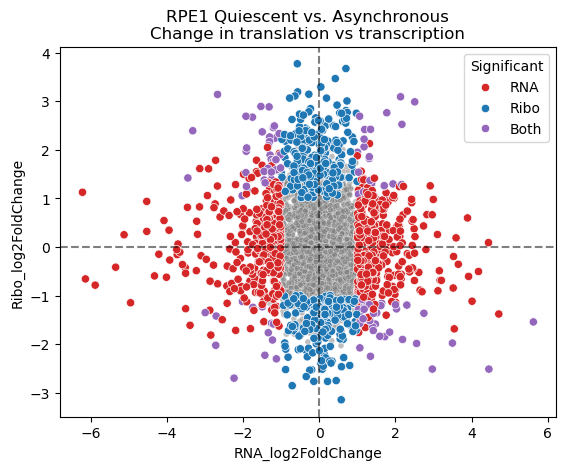

In [193]:
que_vs_async_combined = merge_tis_and_rna_deseqs(que_vs_async_tis, que_vs_async_rna)
_, que_vs_async_filtered = plot_cross_scatter(que_vs_async_combined)
plt.title('RPE1 Quiescent vs. Asynchronous\nChange in translation vs transcription')

Text(0.5, 1.0, 'RPE1 Senescent vs. Asynchronous\nChange in translation vs transcription')

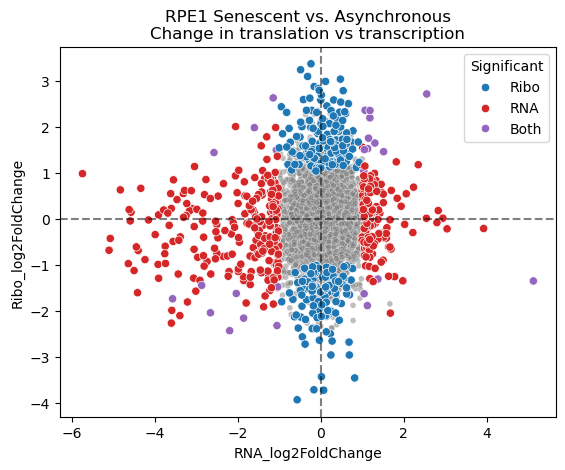

In [194]:
sen_vs_async_rna = rpe1_pairwise_wald_rna_tests[('RPE1_Sen', 'RPE1_Async')].merge(
    tis_metadata[['Gid', 'Symbol']].drop_duplicates(), left_index=True, right_on='Gid', how='left'
)
sen_vs_async_tis = rpe1_pairwise_wald_tests[('RPE1_Sen', 'RPE1_Async')].merge(
    tis_metadata, left_index=True, right_on='TIS', how='left'
)

sen_vs_async_combined = merge_tis_and_rna_deseqs(sen_vs_async_tis, sen_vs_async_rna)
_, sen_vs_async_filtered = plot_cross_scatter(sen_vs_async_combined)
plt.title('RPE1 Senescent vs. Asynchronous\nChange in translation vs transcription')

Text(0.5, 1.0, 'RPE1 Senescent vs. Quiescent\nChange in translation vs transcription')

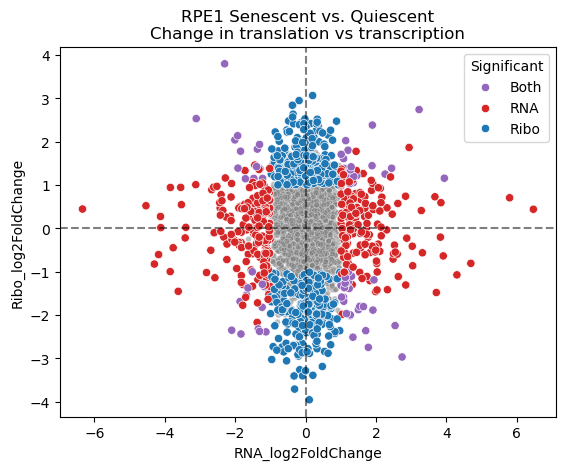

In [195]:
sen_vs_que_rna = rpe1_pairwise_wald_rna_tests[('RPE1_Sen', 'RPE1_Que')].merge(
    tis_metadata[['Gid', 'Symbol']].drop_duplicates(), left_index=True, right_on='Gid', how='left'
)
sen_vs_que_tis = rpe1_pairwise_wald_tests[('RPE1_Sen', 'RPE1_Que')].merge(
    tis_metadata, left_index=True, right_on='TIS', how='left'
)

sen_vs_que_combined = merge_tis_and_rna_deseqs(sen_vs_que_tis, sen_vs_que_rna)
_, sen_vs_que_filtered = plot_cross_scatter(sen_vs_que_combined)
plt.title('RPE1 Senescent vs. Quiescent\nChange in translation vs transcription')

<Axes: xlabel='SignificantAssay', ylabel='NGenes'>

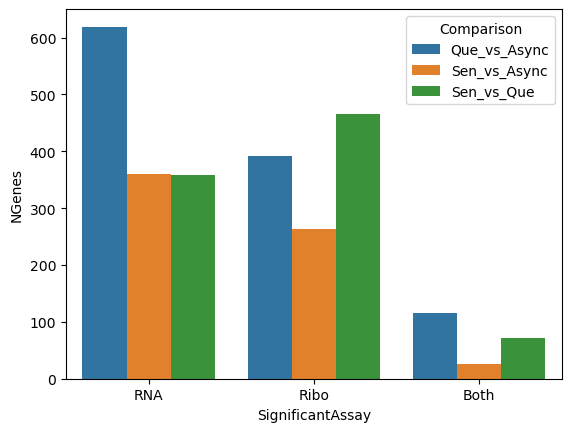

In [204]:
sns.barplot(
    pd.concat([
        que_vs_async_filtered.value_counts('Significant').drop('Neither').rename('Que_vs_Async'),
        sen_vs_async_filtered.value_counts('Significant').drop('Neither').rename('Sen_vs_Async'),
        sen_vs_que_filtered.value_counts('Significant').drop('Neither').rename('Sen_vs_Que')
    ], axis=1).T.melt(ignore_index=False).reset_index(names=['Comparison']).rename({'Significant': 'SignificantAssay', 'value': 'NGenes'}, axis=1),
    x='SignificantAssay', y='NGenes', hue='Comparison'
)